In [29]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import h5py
from scipy import stats

# Settings
base_dir = "results/geocells_with_ci"
r2_key = "R2"  # Change this if the R² key is named differently in your JSON

def collect_r2_stats(model_path, mode):
    # Collect R² values from cluster files
    cluster_r2 = []
    cluster_names = []
    cluster_layers = {}
    best_modality = {}
    landmarks_r2 = None
    wiki_r2 = None

    for file in os.listdir(model_path):
        if file.startswith(f"{mode}_") and file.endswith(".json") and "landmark" not in file:
            cluster =int(file.split('_')[-1].rstrip('.json'))
            with open(os.path.join(model_path, file), "r") as f:
                data = json.load(f)
                r2_value=-1
                for key in data:
                    if data[key][r2_key] > r2_value:
                        r2_value = data[key][r2_key]
                        cluster_layers[cluster]=key
                        best_modality[cluster]="vision"
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        for key in data:    
                            if data[key][r2_key] > r2_value:
                                r2_value = data[key][r2_key]
                                cluster_layers[cluster]=key
                                best_modality[cluster]="text"
                if r2_value is not None:
                    cluster_r2.append(r2_value)
                    cluster_names.append(cluster)
        elif file == f"landmark_{mode}.json":   
            with open(os.path.join(model_path, file), "r") as f:
                data = json.load(f)
                landmarks_r2 = -100
                for key in data:    
                    if data[key][r2_key] > landmarks_r2:
                        landmarks_r2 = data[key][r2_key]
                        cluster_layers["Landmarks"]=key
                        best_modality["Landmarks"]="vision"
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        for key in data:    
                            if data[key][r2_key] > landmarks_r2:
                                landmarks_r2 = data[key][r2_key]
                                cluster_layers["Landmarks"]=key
                                best_modality["Landmarks"]="text"
        elif file == f"wiki_{mode}.json":   
            with open(os.path.join(model_path, file), "r") as f:
                data = json.load(f)
                wiki_r2 = -100
                for key in data:    
                    if data[key][r2_key] > wiki_r2:
                        wiki_r2 = data[key][r2_key]
                        cluster_layers["Wiki"]=key
                        best_modality["Wiki"]="vision"
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        for key in data:    
                            if data[key][r2_key] > wiki_r2:
                                wiki_r2 = data[key][r2_key]
                                cluster_layers["Wiki"]=key
                                best_modality["Wiki"]="text"
    stats = {
        "Landmarks": landmarks_r2,
        #"Wiki":wiki_r2,
    }
    stats.update({cluster_names[k]:v for k,v in enumerate(cluster_r2)})
    return stats, cluster_layers, best_modality

def gather_all_stats(mode): 
    records = []
    for model_name in os.listdir(base_dir):
        print(model_name)
        model_path = os.path.join(base_dir, model_name)
        if not os.path.isdir(model_path):
            continue
        stats,layers,modes = collect_r2_stats(model_path, mode)
        for stat_name, value in stats.items():
            if value is not None:
                records.append({
                    "Model": model_name,
                    "Cluster": stat_name,
                    "Layer":layers[stat_name],
                    "R2": value,
                    "Type": mode.capitalize(),
                    "Modality":modes[stat_name]
                })
    return pd.DataFrame(records)
df = gather_all_stats("activation")

vit-mae-base
gemma-3-12b-it
gemma-3-4b-pt
webssl-dino1b-full2b-224
dinov2-giant
vit-base-patch16-224
clip-vit-large-patch14
metaclip-b16-400m
gemma-3-4b-it
llava-1.5-7b-hf
webssl-mae1b-full2b-224
metaclip-b32-fullcc2.5b
vit-mae-large
clip-vit-base-patch32
metaclip-b16-fullcc2.5b
StreetCLIP
dinov2-base
metaclip-h14-fullcc2.5b
gemma-3-12b-pt
dinov2-small
Qwen2.5-VL-7B-Instruct
Qwen2.5-VL-3B-Instruct
metaclip-l14-fullcc2.5b
dinov2-large
webssl-mae300m-full2b-224
metaclip-l14-400m
vit-large-patch16-224
webssl-dino7b-full8b-224
webssl-dino300m-full2b-224
metaclip-b32-400m


In [2]:
df.sort_values(by='R2')

,Model,Cluster,Layer,R2,Type,Modality
166,vit-base-patch16-224,15,9,0.005416,Activation,vision
8,vit-mae-base,34,11,0.006959,Activation,vision
1,vit-mae-base,16,11,0.008197,Activation,vision
24,vit-mae-base,18,11,0.009716,Activation,vision
7,vit-mae-base,19,11,0.009804,Activation,vision
...,...,...,...,...,...,...
398,gemma-3-12b-pt,Landmarks,17,0.774822,Activation,text
379,metaclip-h14-fullcc2.5b,28,31,0.776363,Activation,vision
475,Qwen2.5-VL-3B-Instruct,Landmarks,32,0.785558,Activation,text
434,Qwen2.5-VL-7B-Instruct,Landmarks,19,0.801466,Activation,text


In [44]:
vision_only = ['vit-mae-base', 'vit-mae-large', 'vit-base-patch16-224',
       'vit-large-patch16-224', 'dinov2-base', 'dinov2-large', 'dinov2-giant', 'webssl-dino7b-full8b-224']

vision_language= ['clip-vit-base-patch32','Qwen2.5-VL-3B-Instruct', 'gemma-3-4b-it', 'Qwen2.5-VL-7B-Instruct',
       'gemma-3-12b-it', 'gemma-3-4b-pt', 'gemma-3-12b-pt',
       'clip-vit-large-patch14', 'metaclip-h14-fullcc2.5b', 'llava-1.5-7b-hf']

In [27]:
cluster_names = [
    "Children",              # 0
    "People Outdoors",              # 1
    "Sports",                # 2
    "Horizon",               # 3
    "People Closeup",        # 4
    "People 1",              # 5
    "Buildings",             # 6
    "People 2",              # 7
    "Birds and Insects",     # 8
    "Flowers",               # 9
    "Food",                  # 10
    "Statues",               # 11
    "Piers",                 # 12
    "Lakes",                 # 13
    "Roads and Railways",    # 14
    "Objects",               # 15
    "Displays",              # 16
    "Signs",                 # 17
    "Musicians",             # 18
    "Text",                  # 19
    "Cliffs and Mountains",  # 20
    "Old Buildings",         # 21
    "Wall",                  # 22
    "Drinks",                # 23
    "Animals",               # 24
    "Cold Places",           # 25
    "Religious Monuments",   # 26
    "Glowing Lights",        # 27
    "Streets",               # 28
    "Colorful Outdoors",     # 29
    "Interiors",             # 30
    "Soil",                  # 31
    "Poles and Columns",     # 32
    "Banks/ Beaches",        # 33
    "Vehicles",              # 34
    "Uncategorized",         # 35
    "Constructions",         # 36
    "Cars",                  # 37
    "Nature",                # 38
    "Large Gatherings",                # 39
]


In [7]:
order = [
  "vit-base-patch16-224",
  "vit-large-patch16-224",
  "clip-vit-large-patch14",
  "clip-vit-base-patch32",
  "vit-mae-base",
  "vit-mae-large",
  "StreetCLIP",
  "dinov2-base",
  "dinov2-large",
  "dinov2-giant",
  "webssl-dino7b-full8b-224",
  "llava-1.5-7b-hf",
  "Qwen2.5-VL-3B-Instruct",
  "Qwen2.5-VL-7B-Instruct",
  "gemma-3-4b-pt",
  "gemma-3-12b-pt",
  "gemma-3-4b-it",
  "gemma-3-12b-it",
  "metaclip-h14-fullcc2.5b"
]
def key(x):
    return order.index(x)

In [ ]:
df=df[df["Model"].isin(order)]
df = df.assign(f = df['Model'].apply(key)).sort_values(['f','Cluster']).drop('f', axis=1)

In [28]:
df["Cluster Name"] = df["Cluster"].apply(lambda c: cluster_names[c] if c !="Landmarks" else c)

In [10]:
def recover_error(df):
    lines = df.to_dict(orient="records")
    for row in lines:
        if row['Modality']=='vision':
            if row['Cluster'] != 'Landmarks':
                filename=f'results/geocells_with_ci/{row["Model"]}/activation_{row["Cluster"]}.json'
            else:
                filename=f'results/geocells_with_ci/{row["Model"]}/landmark_activation.json'
        else:
            if row['Cluster'] != 'Landmarks':
                filename=f'results/geocells_with_ci/{row["Model"]}/text_activation_{row["Cluster"]}.json'
            else:
                filename=f'results/geocells_with_ci/{row["Model"]}/text_landmark_activation.json'
        with open(filename, "r") as f:
            data = json.load(f)
            try:
                row['CI'] = 1.96*data[str(row['Layer'])]['r2_error']
            except:
                print(data)
                raise Exception()
    return pd.DataFrame(lines)
df2=recover_error(df)

In [ ]:
df2['R2'] = df2['R2'].apply(lambda x: '{:.2f}'.format(x))
df2['CI'] = df2['CI'].apply(lambda x: '±'+'{:.2f}'.format(x,3))
df2['val'] = df2['R2']+df2['CI']                        

In [ ]:
heatmap_data = df.pivot_table(
    index="Model",
    columns="Cluster Name",
    values="R2"
)
heatmap_data["avg"] = heatmap_data.mean(axis=1, numeric_only=True)
display(heatmap_data["avg"])
heatmap_data = heatmap_data.sort_values(by="avg").drop(columns="avg")

col_order = heatmap_data.mean(axis=0, numeric_only=True).sort_values().index
col_order = [c for c in col_order if "Trash" not in c]
heatmap_data = heatmap_data[col_order]

vision_only = ['vit-mae-base', 'vit-mae-large', 'vit-base-patch16-224',
       'vit-large-patch16-224', 'dinov2-base', 'dinov2-large', 'dinov2-giant', 'webssl-dino7b-full8b-224']

vision_language= ['clip-vit-base-patch32','Qwen2.5-VL-3B-Instruct', 'gemma-3-4b-it', 'Qwen2.5-VL-7B-Instruct',
       'gemma-3-12b-it', 'gemma-3-4b-pt', 'gemma-3-12b-pt',
       'clip-vit-large-patch14', 'metaclip-h14-fullcc2.5b', 'llava-1.5-7b-hf']

heatmap_data = heatmap_data.loc[vision_only+vision_language]

In [ ]:
heatmap_ci = df2.pivot(
    index="Model",
    columns="Cluster Name",
    values="val"
)
heatmap_ci=heatmap_ci[heatmap_data.columns]
heatmap_ci = heatmap_ci.rename_axis(None, axis=1)
heatmap_ci= heatmap_ci.loc[heatmap_data.index]

Model
dinov3-vitb16-pretrain-lvd1689m    0.210018
dinov3-vitl16-pretrain-lvd1689m    0.236576
Name: avg, dtype: float64

/tmp/ipykernel_72502/761014553.py:52: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


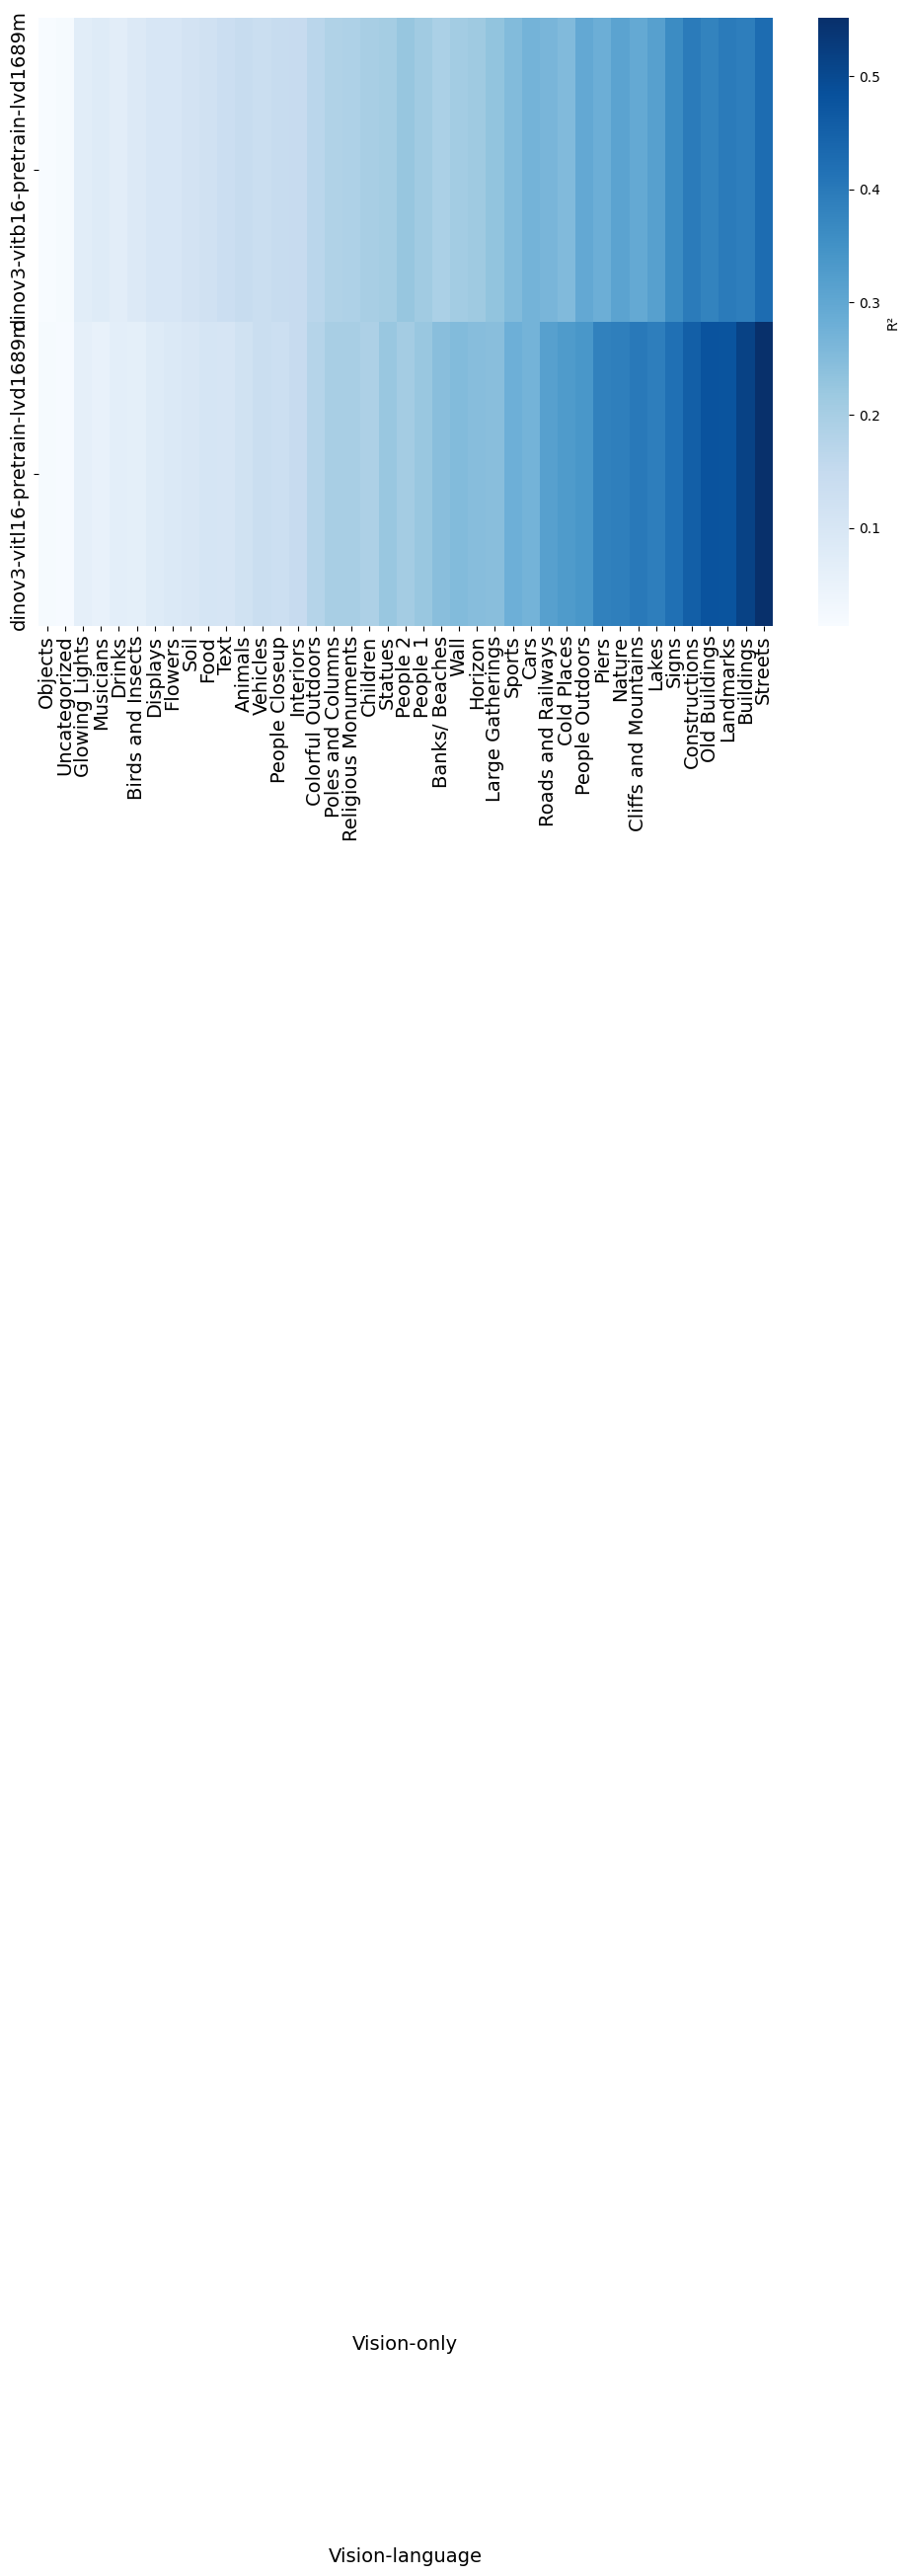

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 8))
ax =  sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=False,  # shows R² values
    fmt=".2f",
    cbar_kws={'label': 'R²'}
)

ax.set_xticklabels(ax.get_xmajorticklabels(), fontsize = 14)
ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 14)
sep_index = len(vision_only)
ax.hlines(sep_index, *ax.get_xlim(), colors="black", linewidth=2)
# Add section labels
ax.text(
    heatmap_data.shape[1] / 2, sep_index-0.35,  # x = middle of heatmap, y = just above first row
    "Vision-only",
    ha="center", va="center", fontsize=14, 
)
ax.text(
    heatmap_data.shape[1] / 2, sep_index + 0.35,  # x = middle, y = just below separation line
    "Vision-language",
    ha="center", va="center", fontsize=14, 
)
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.savefig("plots/performance_heatmap.pdf")
plt.show()

In [9]:
def calculate_row_distance(row):
    p1 = np.array([row["true_latitude"],row["true_longitude"]])
    p2 = np.array([row["predicted_latitude"],row["predicted_longitude"]])
    return np.linalg.norm(p1 - p2)

def get_images_ids(df):
    lines = []
    for line in df.to_dict(orient="records"):
        model = line["Model"]
        model_path = os.path.join(base_dir,model)
        layer = line["Layer"]
        mode = line["Modality"]
        cluster = f"{line['Cluster']}" if line["Cluster"]!="Landmarks" else line["Cluster"].lower()
        if mode=="text":
            cluster+="_text"
        prediction_path = os.path.join(os.path.join(os.path.join(model_path,cluster),"predictions"),f"layer_{layer}.csv")
        predictions = pd.read_csv(prediction_path)
        predictions["distance"] = predictions.apply(calculate_row_distance,axis=1)
        predictions=predictions[(np.abs(stats.zscore(predictions["distance"])) < 3)]
        ids = predictions.sample(n=2,random_state=0)["id"].tolist()
        line.update({
            "sample_1":ids[0],
            "sample_2":ids[1]
        })
        lines.append(line)
    return pd.DataFrame(lines)
df = get_images_ids(df)

In [10]:
plot_df =df.copy()

In [11]:
plot_df["quant"] = plot_df["R2"]//0.10

In [12]:
plot_df.sort_values(by="R2")

,Model,Cluster,Layer,R2,Type,Modality,Cluster Name,sample_1,sample_2,quant
187,vit-mae-base,23,9,0.005782,Activation,vision,Drinks,1954,4184,0.0
179,vit-mae-base,15,11,0.005872,Activation,vision,Objects,2965,2827,0.0
196,vit-mae-base,32,10,0.007926,Activation,vision,Poles and Columns,3742,2054,0.0
220,vit-mae-large,15,18,0.008394,Activation,vision,Objects,2965,2827,0.0
199,vit-mae-base,35,11,0.009790,Activation,vision,Uncategorized,898,953,0.0
...,...,...,...,...,...,...,...,...,...,...
409,llava-1.5-7b-hf,Landmarks,23,0.747101,Activation,vision,Landmarks,4676,4107,7.0
573,gemma-3-12b-pt,Landmarks,17,0.752928,Activation,text,Landmarks,4739,4102,7.0
561,gemma-3-12b-pt,28,17,0.758602,Activation,text,Streets,4601,425,7.0
110,clip-vit-large-patch14,28,23,0.765135,Activation,vision,Streets,3838,2252,7.0


In [13]:
plot_models = [
  "vit-large-patch16-224",
  "clip-vit-large-patch14",
  "vit-mae-large",
  "dinov2-giant",
  "llava-1.5-7b-hf",
  "Qwen2.5-VL-7B-Instruct",
  "gemma-3-12b-pt"
]

plot_df = plot_df[plot_df["Model"].isin(plot_models)].sort_values(by="R2")

In [14]:
cluster_choices = {model:[[],[],[],[],[],[],[],[],[],[]] for model in plot_models}


seen_clusters=set()
for model in plot_models:
    cluster_quant = plot_df.loc[(plot_df["Cluster"]=="Landmarks") & (plot_df["Model"]==model)].iloc[0]["quant"]
    cluster_choices[model][int(cluster_quant)].append("Landmarks")
seen_clusters.add("Landmarks")
for line in plot_df.sort_values("R2",ascending=False).reset_index().to_dict(orient="records"):
    if line["Cluster"] in seen_clusters:
        continue
    for model in plot_models:
        try:
            cluster_quant = plot_df.loc[(plot_df["Cluster"]==line["Cluster"]) & (plot_df["Model"]==model)].iloc[0]["quant"]
            if len(cluster_choices[model][int(cluster_quant)])<1 and line["Cluster"] not in cluster_choices[model][int(cluster_quant)]:
                cluster_choices[model][int(cluster_quant)].append(line["Cluster"])
        except:
            pass
    seen_clusters.add(line["Cluster"])

In [15]:
plot_df.sort_values("R2")

,Model,Cluster,Layer,R2,Type,Modality,Cluster Name,sample_1,sample_2,quant
220,vit-mae-large,15,18,0.008394,Activation,vision,Objects,2965,2827,0.0
228,vit-mae-large,23,23,0.013352,Activation,vision,Drinks,2965,3770,0.0
240,vit-mae-large,35,20,0.013432,Activation,vision,Uncategorized,2564,3656,0.0
224,vit-mae-large,19,15,0.013504,Activation,vision,Text,871,951,0.0
221,vit-mae-large,16,20,0.013770,Activation,vision,Displays,2961,2815,0.0
...,...,...,...,...,...,...,...,...,...,...
409,llava-1.5-7b-hf,Landmarks,23,0.747101,Activation,vision,Landmarks,4676,4107,7.0
573,gemma-3-12b-pt,Landmarks,17,0.752928,Activation,text,Landmarks,4739,4102,7.0
561,gemma-3-12b-pt,28,17,0.758602,Activation,text,Streets,4601,425,7.0
110,clip-vit-large-patch14,28,23,0.765135,Activation,vision,Streets,3838,2252,7.0


In [16]:
sample_per_cluster = plot_df.drop_duplicates(subset="Cluster")[["Cluster","sample_1"]].set_index("Cluster").to_dict(orient="index")

In [17]:
data = {
}

for model in cluster_choices:
    data[model]=[]
    for i,quant in enumerate(cluster_choices[model]):
        if len(quant)==1:
            sample = sample_per_cluster[quant[0]]["sample_1"]
            if quant[0]=="Landmarks":
                sample=383
            data[model].append({"quant":i,"imgs":sample,"clusters":quant[0]
                           ,"R2":0+(0.1*i)})

In [18]:
data

{'vit-large-patch16-224': [{'quant': 0,
   'imgs': 903,
   'clusters': 32,
   'R2': 0.0},
  {'quant': 1, 'imgs': 2529, 'clusters': 39, 'R2': 0.1},
  {'quant': 2, 'imgs': 383, 'clusters': 'Landmarks', 'R2': 0.2}],
 'clip-vit-large-patch14': [{'quant': 1,
   'imgs': 2564,
   'clusters': 35,
   'R2': 0.1},
  {'quant': 2, 'imgs': 2562, 'clusters': 27, 'R2': 0.2},
  {'quant': 3, 'imgs': 2529, 'clusters': 26, 'R2': 0.30000000000000004},
  {'quant': 4, 'imgs': 1438, 'clusters': 33, 'R2': 0.4},
  {'quant': 5, 'imgs': 2890, 'clusters': 1, 'R2': 0.5},
  {'quant': 6, 'imgs': 1417, 'clusters': 17, 'R2': 0.6000000000000001},
  {'quant': 7,
   'imgs': 383,
   'clusters': 'Landmarks',
   'R2': 0.7000000000000001}],
 'vit-mae-large': [{'quant': 0, 'imgs': 2533, 'clusters': 28, 'R2': 0.0},
  {'quant': 1, 'imgs': 383, 'clusters': 'Landmarks', 'R2': 0.1}],
 'dinov2-giant': [{'quant': 0, 'imgs': 2965, 'clusters': 23, 'R2': 0.0},
  {'quant': 1, 'imgs': 2580, 'clusters': 29, 'R2': 0.1},
  {'quant': 2, 'imgs

In [19]:
landmarks_file = h5py.File("../vit/geocells_landmarks.hdf5")
cluster_file = h5py.File("../vit/geocells_clusters.hdf5")

def get_cluster_idx(data,cluster,sample_size=None): 
    idx = np.where(data["clusters"][:]==cluster)[0]
    if sample_size is not None or sample_size<idx.shape[0]:
        np.random.seed(42)
        idx=np.random.choice(idx, sample_size, replace=False)
    return idx
            
idxs_per_cluster={}

for cluster in range(40):
    sample_size=5000
    cl = f'{cluster}'.encode()
    cluster_indexes = get_cluster_idx(cluster_file,cl,sample_size)
    idxs_per_cluster[cluster] = cluster_indexes

_,indices = np.unique(landmarks_file["landmark_ids"],return_index=True)

idxs_per_cluster["Landmarks"]=indices

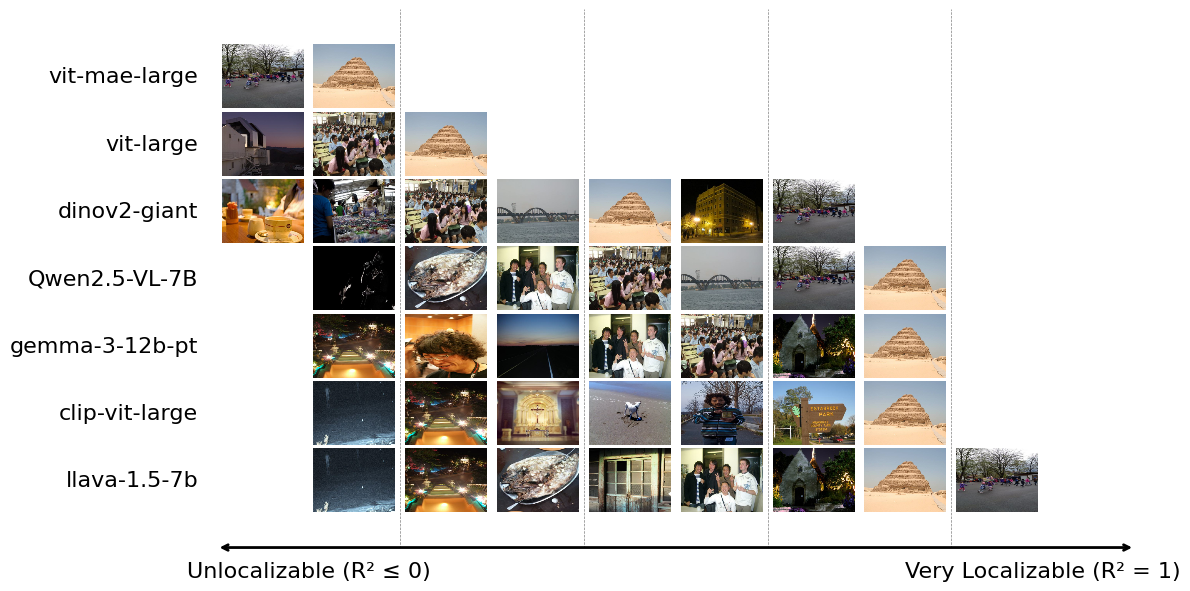

In [20]:
import cv2
# Prepare figure
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(data) + 1)
ax.axis("off")

# Draw the arrow scale at bottom
ax.annotate(
    "", xy=(1, 0), xytext=(0, 0),
    arrowprops=dict(arrowstyle="<->", lw=2, color="black")
)
ax.text(0.1, -0.2, "Unlocalizable (R² ≤ 0)", ha="center", va="top", fontsize=16)
ax.text(0.9, -0.2, "Very Localizable (R² = 1)", ha="center", va="top", fontsize=16)
order = ["vit-mae-large","vit-large-patch16-224","dinov2-giant","Qwen2.5-VL-7B-Instruct","gemma-3-12b-pt","clip-vit-large-patch14","llava-1.5-7b-hf"]
order.reverse()
model_names = ["vit-mae-large","vit-large","dinov2-giant","Qwen2.5-VL-7B","gemma-3-12b-pt","clip-vit-large","llava-1.5-7b"]
model_names.reverse()
# Draw each model row above the scale
for idx, model in enumerate(order, start=1):
    clusters = data[model]
    y_pos = idx  # vertical position for the row
    ax.text(-0.02, y_pos, model_names[idx-1], ha="right", va="center", fontsize=16)
    
    for c in clusters:
        r2 = np.clip(c["R2"], 0, 1)
        if c["clusters"]=="Landmarks":
            img = landmarks_file["images"][c["imgs"]]
        else:
            img = cluster_file["images"][idxs_per_cluster[c["clusters"]][c["imgs"]]]
        img = np.frombuffer(img, dtype=np.uint8)
        img = cv2.imdecode(img, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (295, 230)) 
        imagebox = OffsetImage(img, zoom=0.2)
        ab = AnnotationBbox(imagebox, (r2+0.05, y_pos), frameon=False)
        ax.add_artist(ab)

# Optionally add vertical lines for 0.25 intervals
for boundary in [0.2, 0.4,0.6, 0.8]:
    ax.axvline(boundary, color="gray", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.savefig("plots/localization_plot.pdf")
plt.show()


## Coefficients

In [21]:
from scipy import stats

def collect_coefficients(model_path, mode):
    # Collect R² values from cluster files
    cluster_latitude_coeff = []
    cluster_longitude_coeff = []
    cluster_r2 = []
    cluster_names = []
    cluster_layers = {}
    best_modality = {}
    landmarks_r2 = None
    landmarks_latitude=None
    landmarks_longitude=None

    for file in os.listdir(model_path):
        if file.startswith(f"{mode}_") and file.endswith(".json") and "landmark" not in file:
            cluster =int(file.split('_')[-1].rstrip('.json'))
            with open(os.path.join(model_path, file), "r") as f:
                data = json.load(f)
                r2_value=-1
                latitudes =[]
                longitudes=[]
                for key in data:
                    if data[key][r2_key] > r2_value:
                        r2_value = data[key][r2_key]
                        cluster_layers[cluster]=key
                        best_modality[cluster]="vision"
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        for key in data:    
                            if data[key][r2_key] > r2_value:
                                r2_value = data[key][r2_key]
                                cluster_layers[cluster]=key
                                best_modality[cluster]="text"
        elif file == f"landmark_{mode}.json":   
            with open(os.path.join(model_path, file), "r") as f:
                data = json.load(f)
                landmarks_r2 = -100
                for key in data:    
                    if data[key][r2_key] > landmarks_r2:
                        landmarks_r2 = data[key][r2_key]
                        cluster_layers["Landmarks"]=key
                        best_modality["Landmarks"]="vision"
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        for key in data:    
                            if data[key][r2_key] > landmarks_r2:
                                landmarks_r2 = data[key][r2_key]
                                cluster_layers["Landmarks"]=key
                                best_modality["Landmarks"]="text"
    #find most frequent layers across clusters
    layer = str(stats.mode([int(v) for v in cluster_layers.values()]).mode)
    modality= "vision" if (stats.mode([0 if best_modality[k]=="vision" else 1 for k in cluster_layers.keys()  ]).mode)==0 else "text"

    for file in os.listdir(model_path):
        if file.startswith(f"{mode}_") and file.endswith(".json") and "landmark" not in file:
            cluster =int(file.split('_')[-1].rstrip('.json'))
            if modality=="vision":
                with open(os.path.join(model_path, file), "r") as f:
                    data = json.load(f)
                    r2_value = data[layer][r2_key]
                    latitudes = data[layer]["latitude_coefficients"]
                    longitudes = data[layer]["longitude_coefficients"]
                    cluster_layers[cluster]=layer
                    best_modality[cluster]="vision"
            else:
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        r2_value = data[layer][r2_key]
                        latitudes = data[layer]["latitude_coefficients"]
                        longitudes = data[layer]["longitude_coefficients"]
                        cluster_layers[cluster]=layer
                        best_modality[cluster]="text"
            if r2_value is not None:
                cluster_latitude_coeff.append(latitudes)
                cluster_longitude_coeff.append(longitudes)
                cluster_names.append(cluster)
                cluster_r2.append(r2_value)
        elif file == f"landmark_{mode}.json":
            if modality=="vision":
                with open(os.path.join(model_path, file), "r") as f:
                    data = json.load(f)
                    landmarks_r2 = data[layer][r2_key]
                    landmarks_latitude = data[layer]["latitude_coefficients"]
                    landmarks_longitude = data[layer]["longitude_coefficients"]
                    cluster_layers["Landmarks"]=layer
                    best_modality["Landmarks"]="vision"
            else:
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        landmarks_r2 = data[layer][r2_key]
                        cluster_layers["Landmarks"]=layer
                        landmarks_latitude = data[layer]["latitude_coefficients"]
                        landmarks_longitude = data[layer]["longitude_coefficients"]
                        best_modality["Landmarks"]="text" 
            
    statstics = {
        "Landmarks": {"latitude":landmarks_latitude,"longitude":landmarks_longitude, "r2":landmarks_r2}
    }
    statstics.update({v:{"latitude":cluster_latitude_coeff[k],"longitude":cluster_longitude_coeff[k], "r2":cluster_r2[k]} for k,v in enumerate(cluster_names)})
    return statstics, cluster_layers, best_modality

def gather_coefficients(mode): 
    records = []
    for model_name in os.listdir(base_dir):
        print(model_name)
        model_path = os.path.join(base_dir, model_name)
        if not os.path.isdir(model_path):
            continue
        statstics,layers,modes = collect_coefficients(model_path, mode)
        for stat_name, value in statstics.items():
            if value is not None:
                records.append({
                    "Model": model_name,
                    "Cluster": stat_name,
                    "Layer":layers[stat_name],
                    "Latitude": np.array(value["latitude"]),
                    "Longitude": np.array(value["longitude"]),
                    "R2":np.array(value["r2"]),
                    "Type": mode.capitalize(),
                    "Modality":modes[stat_name]
                })
    return pd.DataFrame(records)
coef_df = gather_coefficients("activation")

vit-mae-base
gemma-3-12b-it
gemma-3-4b-pt
webssl-dino1b-full2b-224
dinov2-giant
vit-base-patch16-224
clip-vit-large-patch14
metaclip-b16-400m
gemma-3-4b-it
llava-1.5-7b-hf
webssl-mae1b-full2b-224
metaclip-b32-fullcc2.5b
vit-mae-large
clip-vit-base-patch32
metaclip-b16-fullcc2.5b
StreetCLIP
dinov2-base
gemma-3-12b-pt
dinov2-small
Qwen2.5-VL-7B-Instruct
Qwen2.5-VL-3B-Instruct
metaclip-l14-fullcc2.5b
dinov2-large
webssl-mae300m-full2b-224
vit-large-patch16-224
webssl-dino300m-full2b-224
metaclip-b32-400m


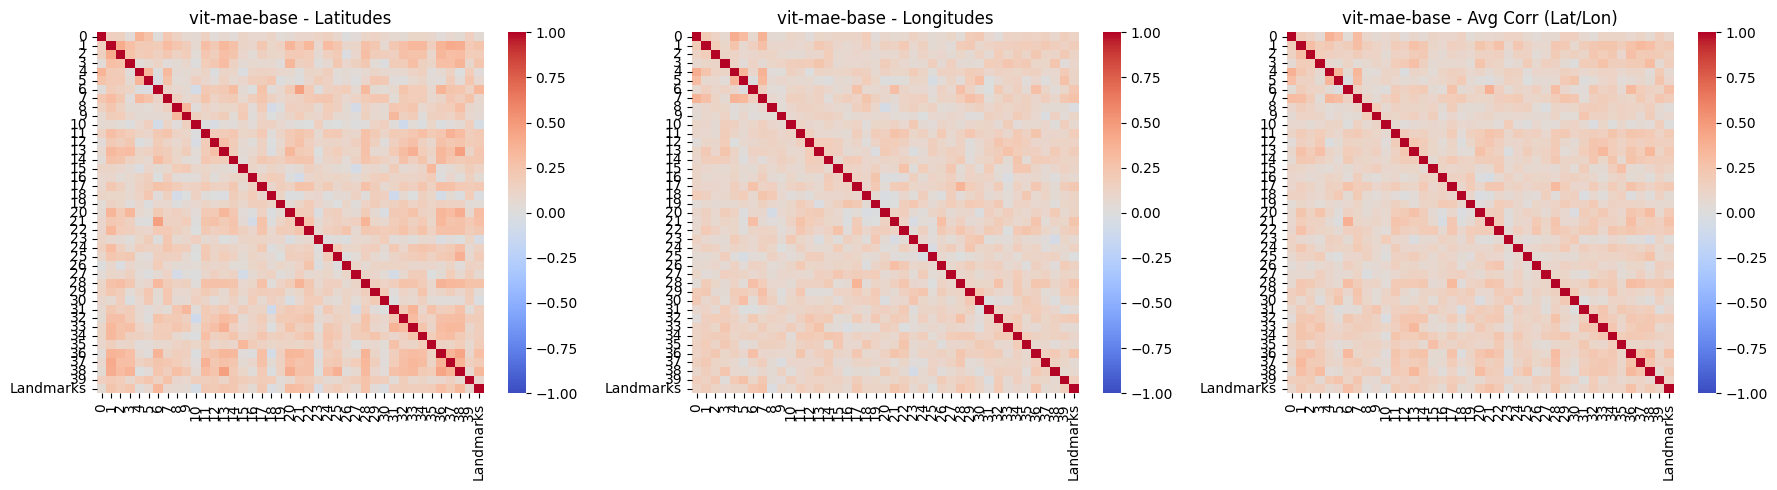

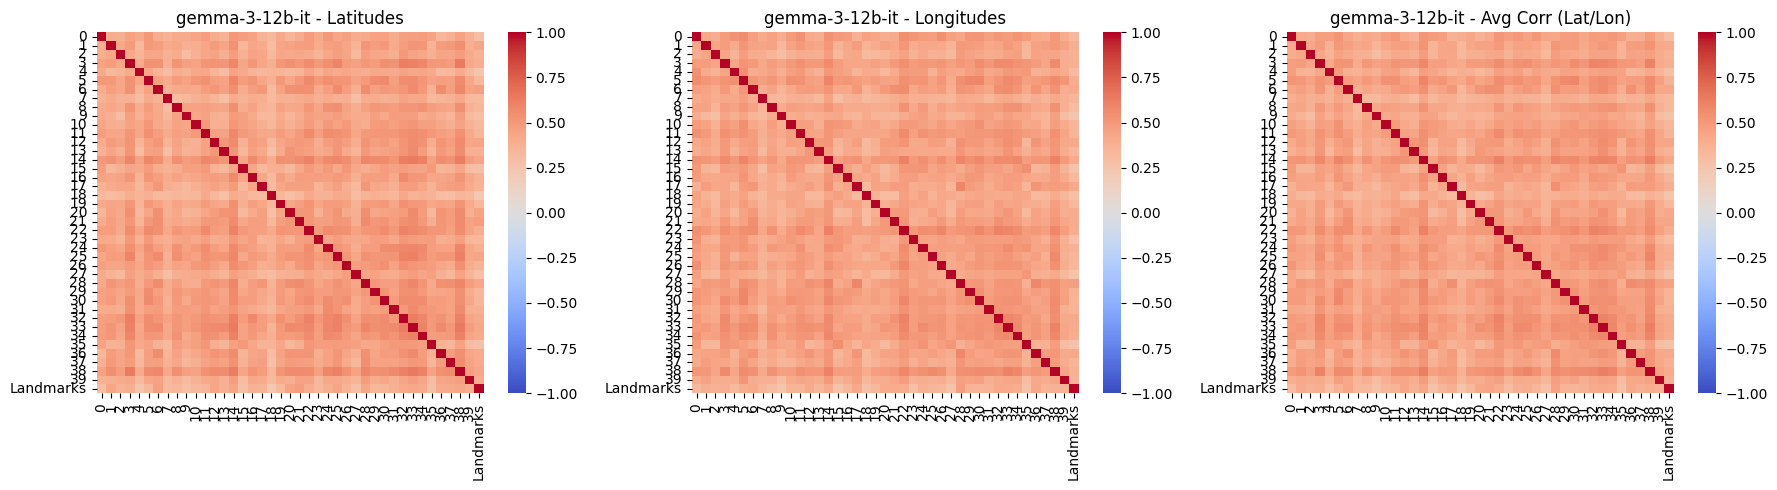

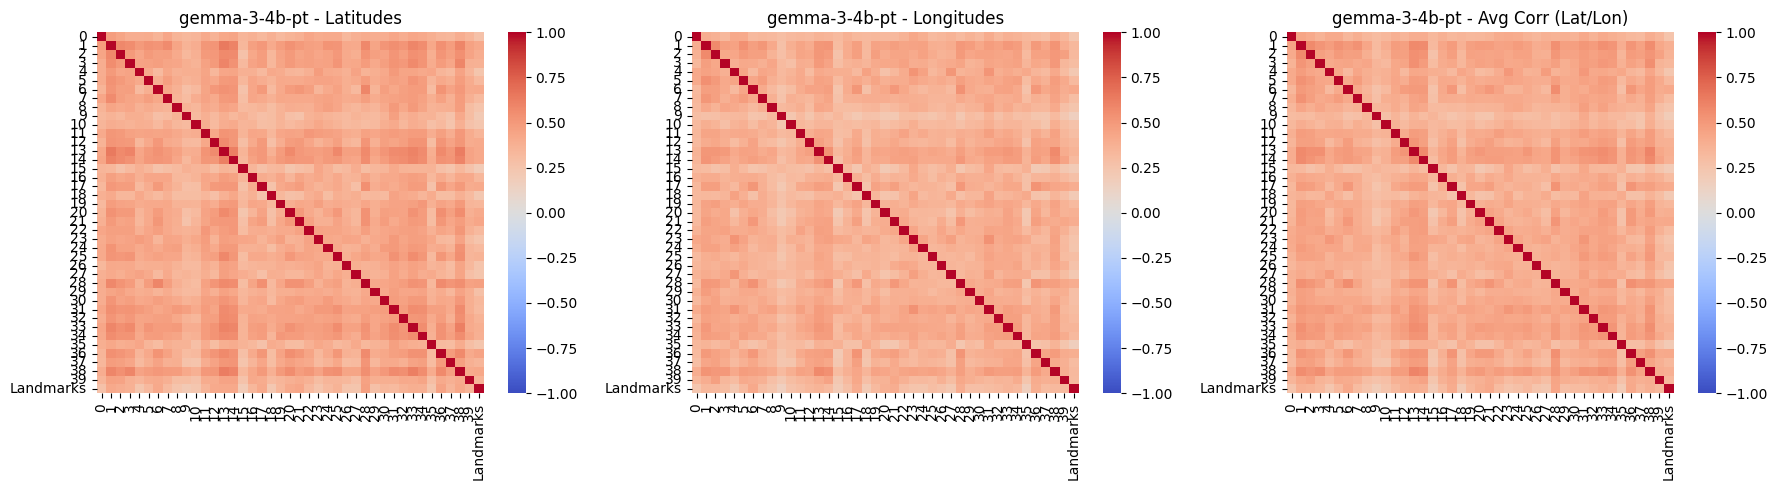

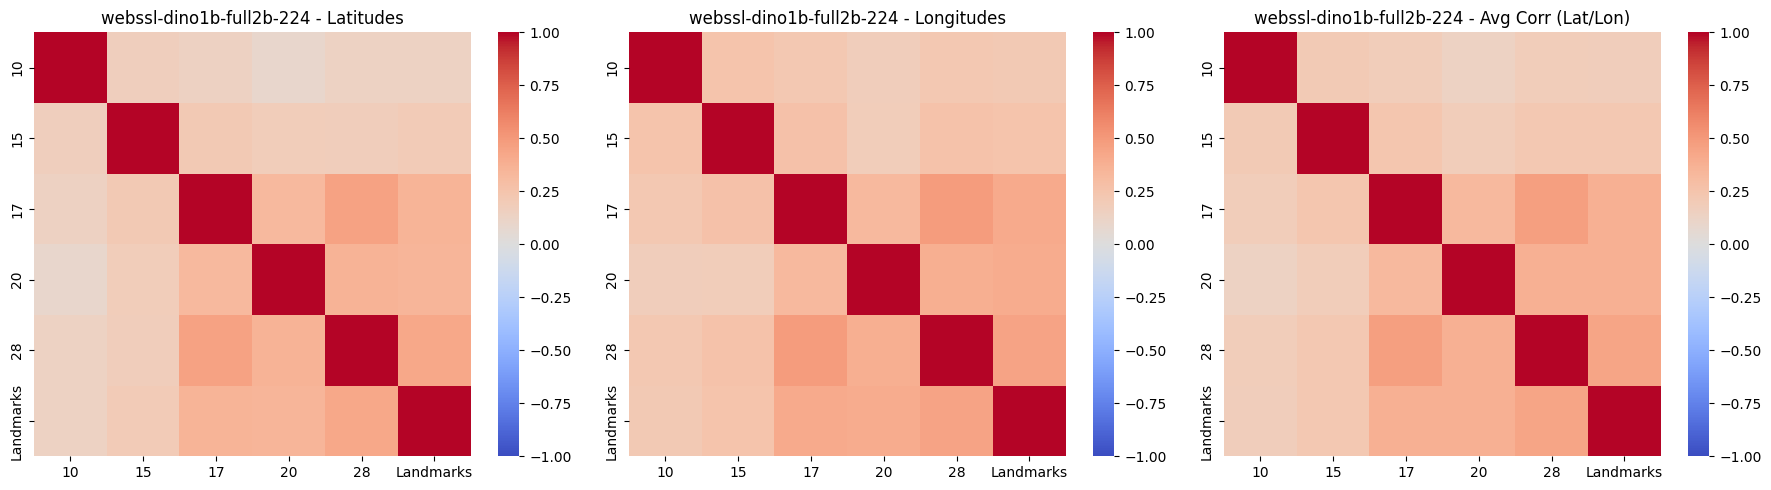

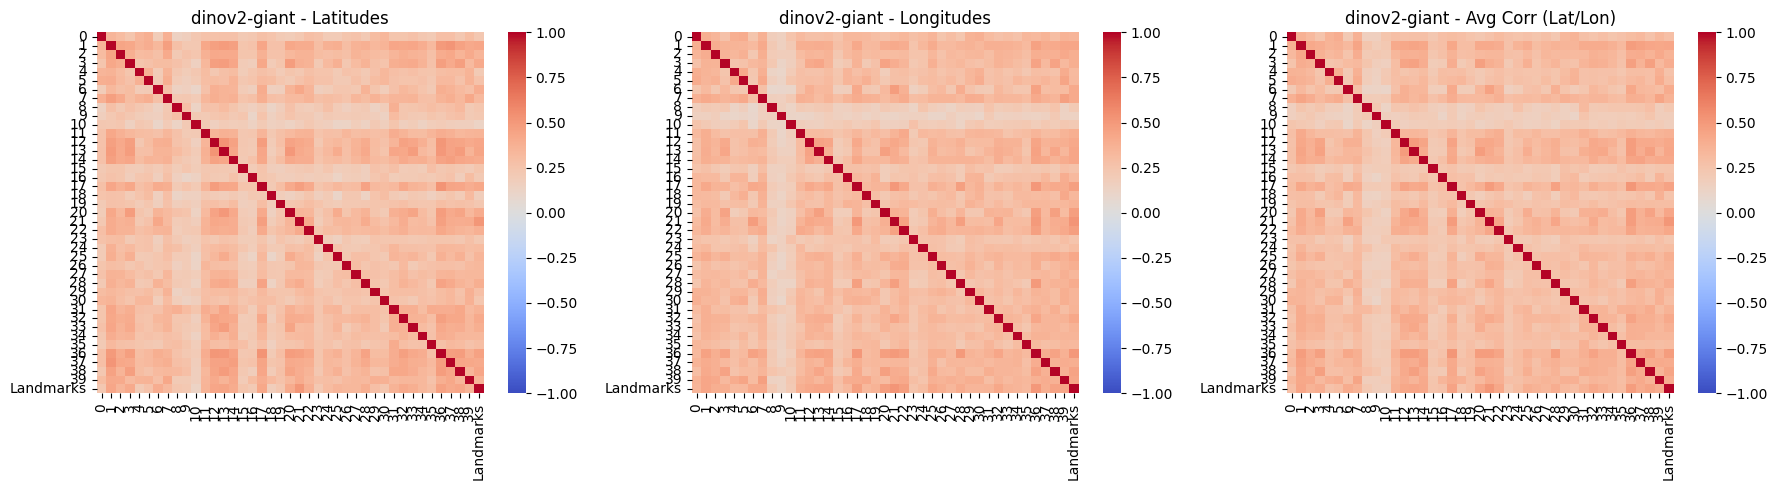

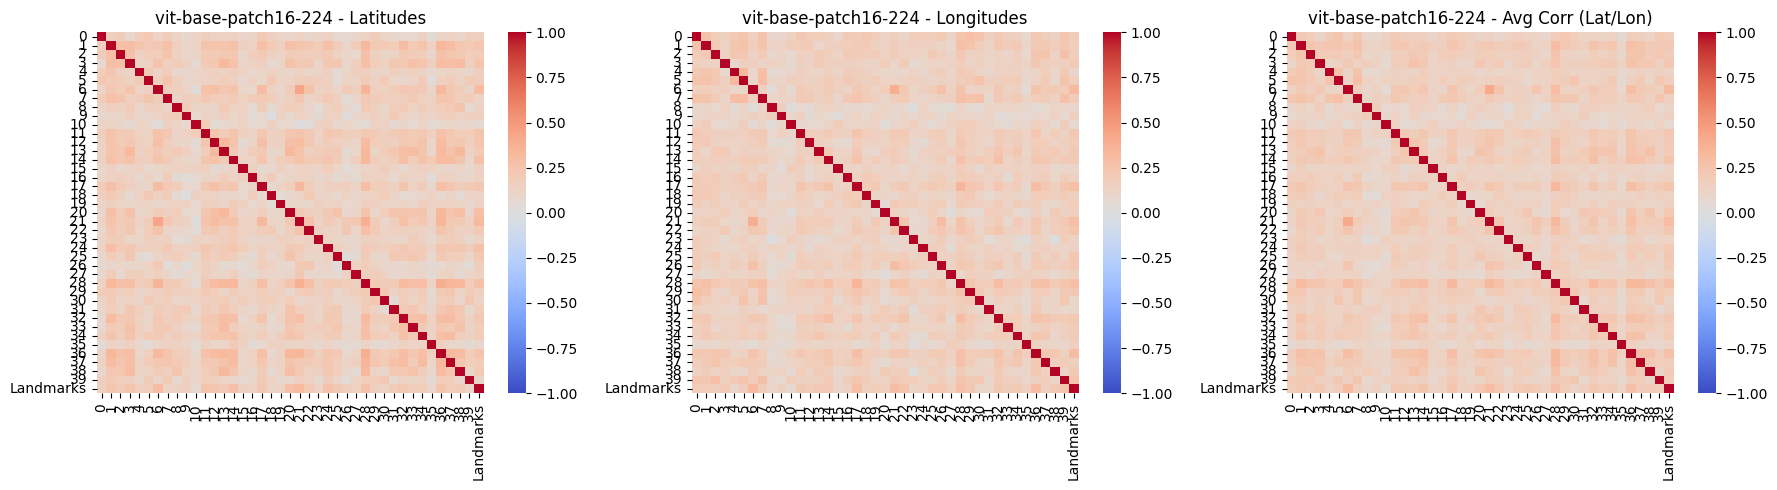

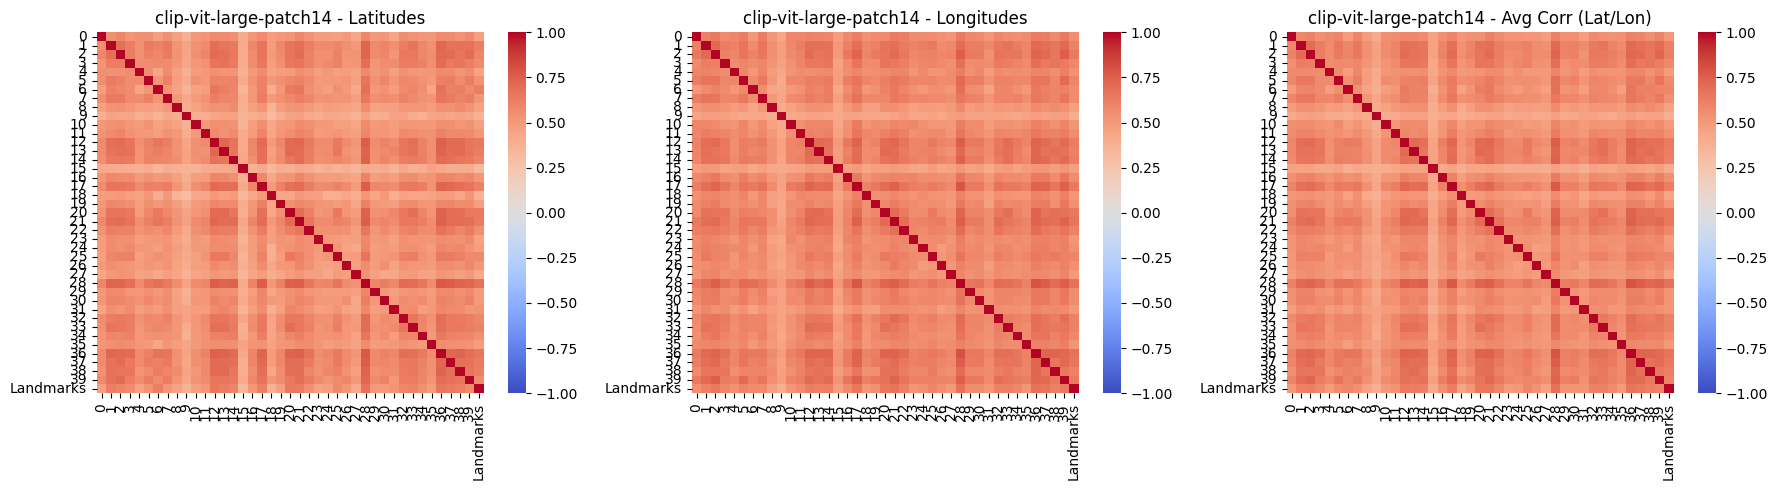

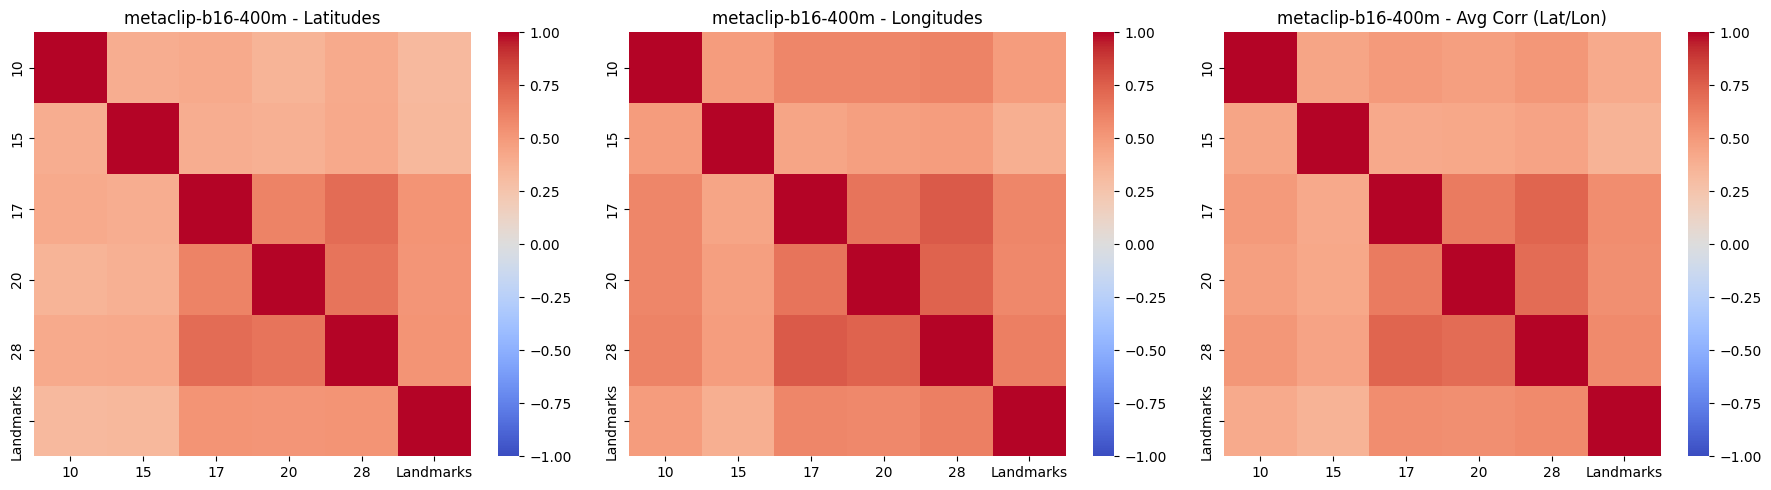

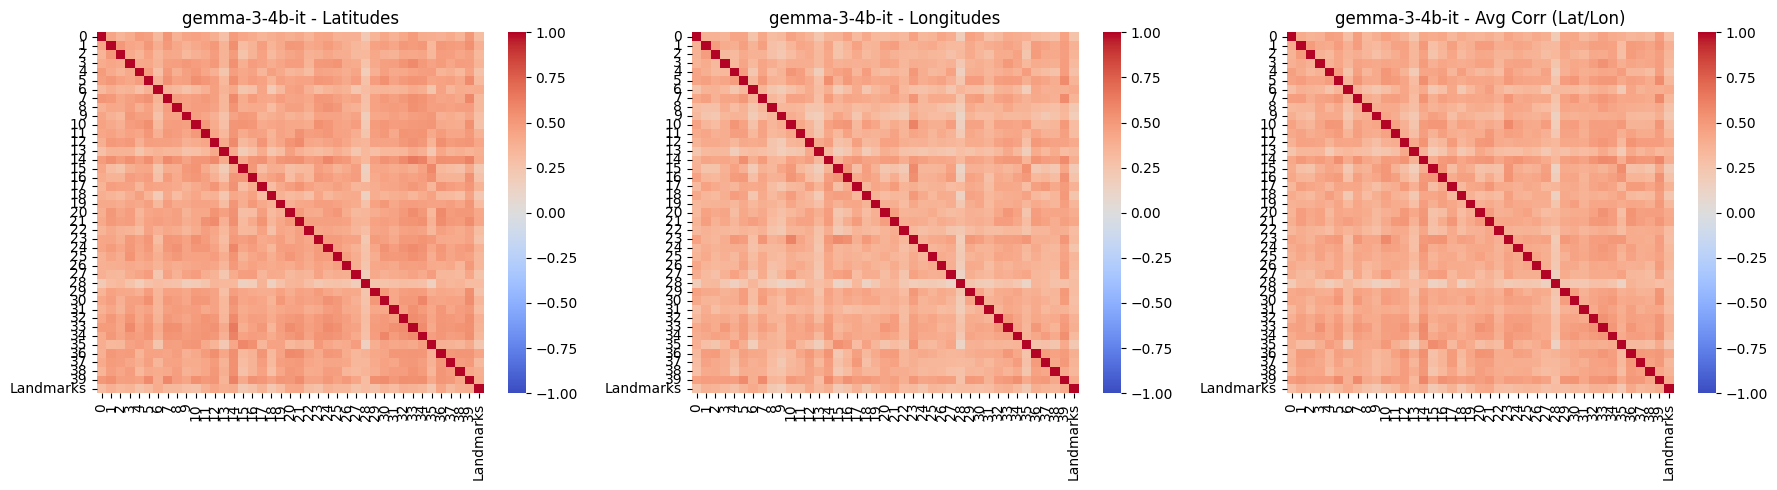

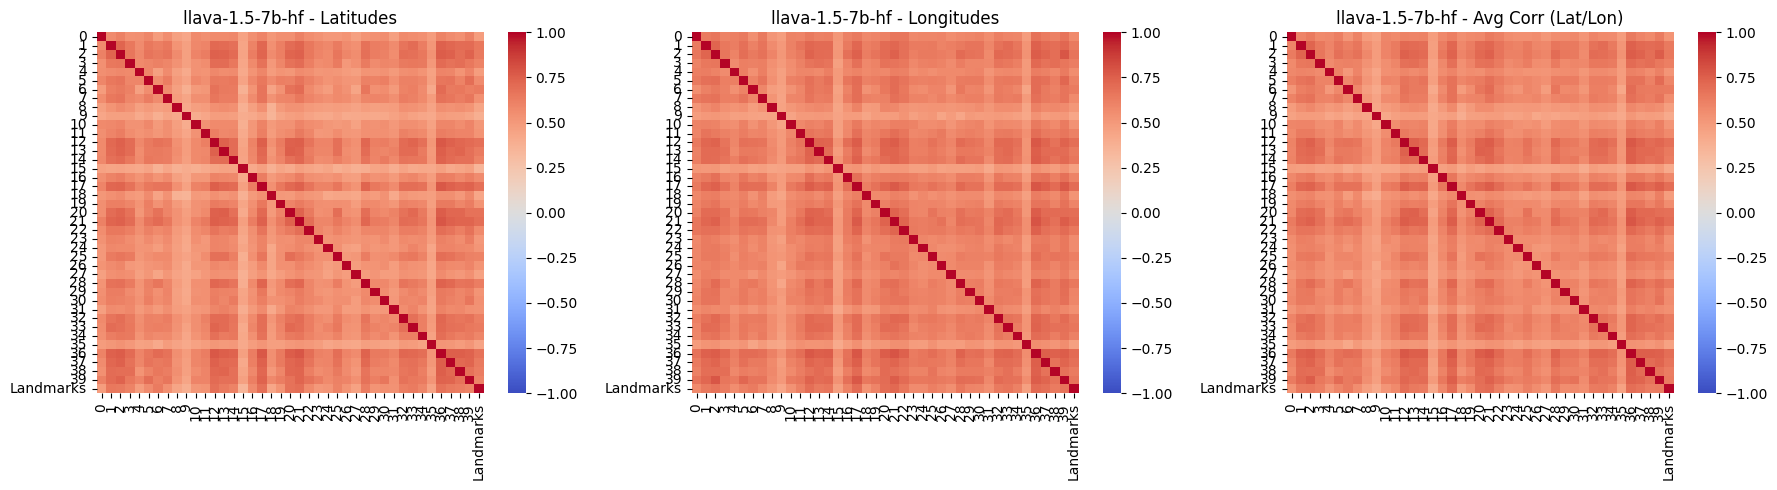

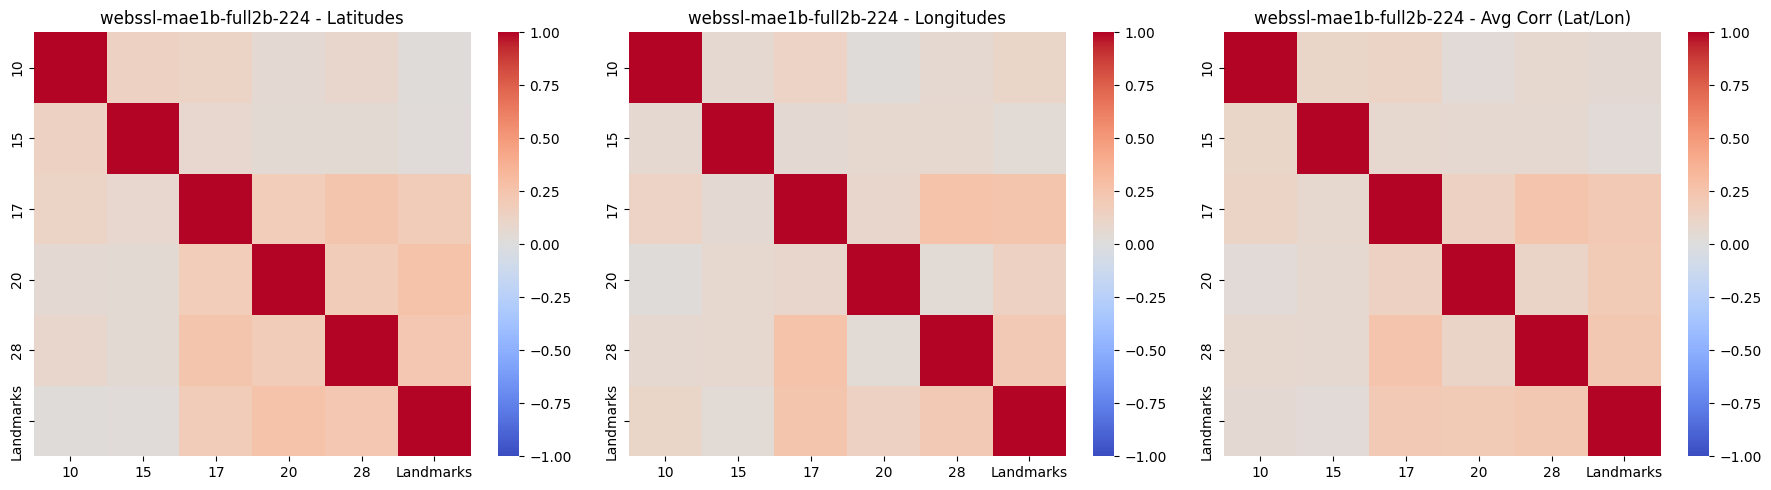

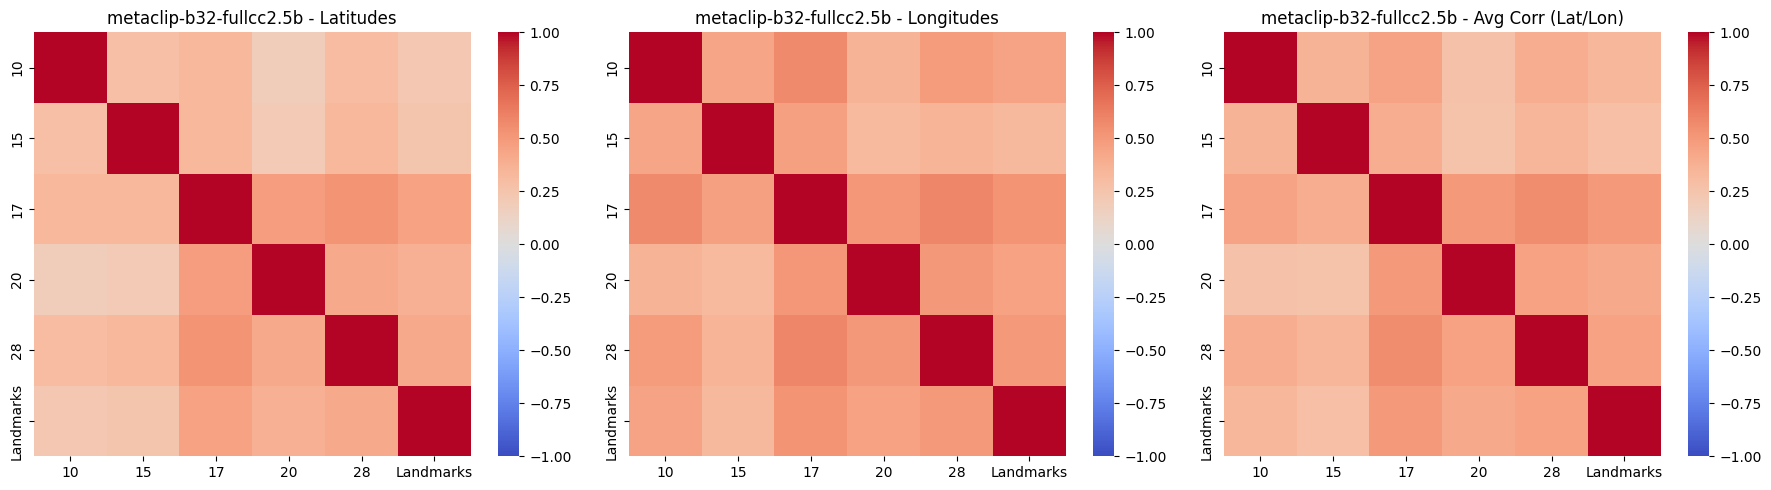

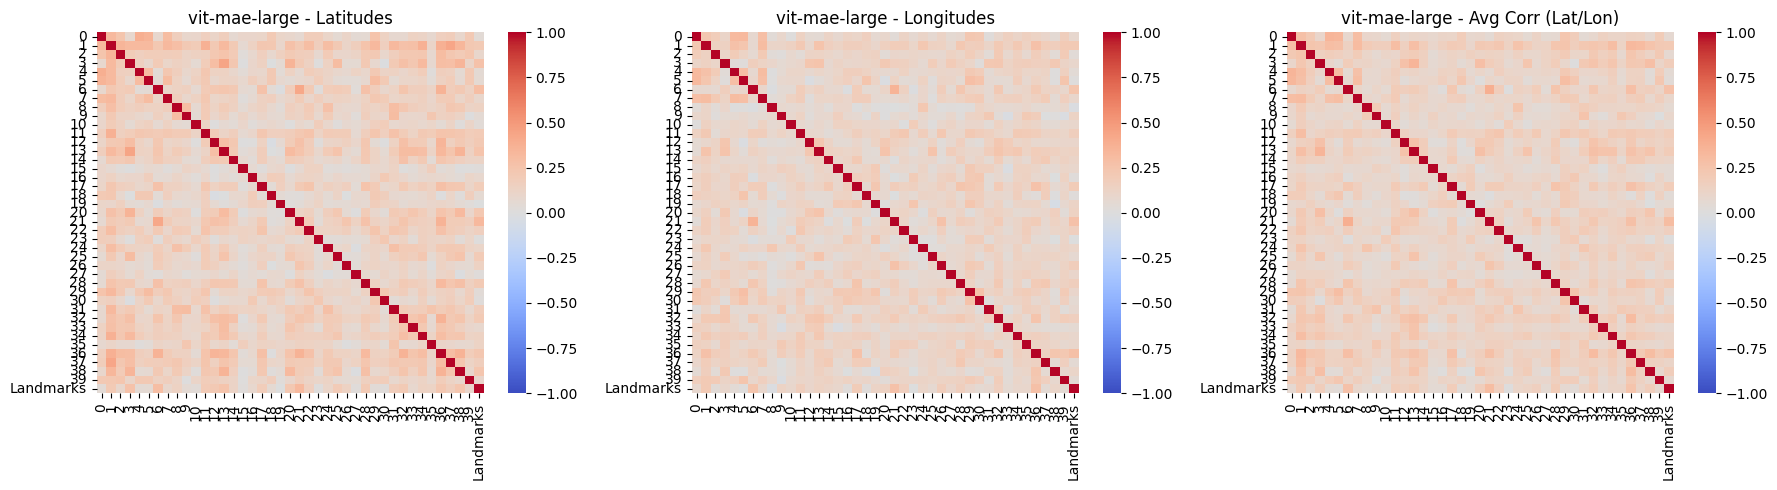

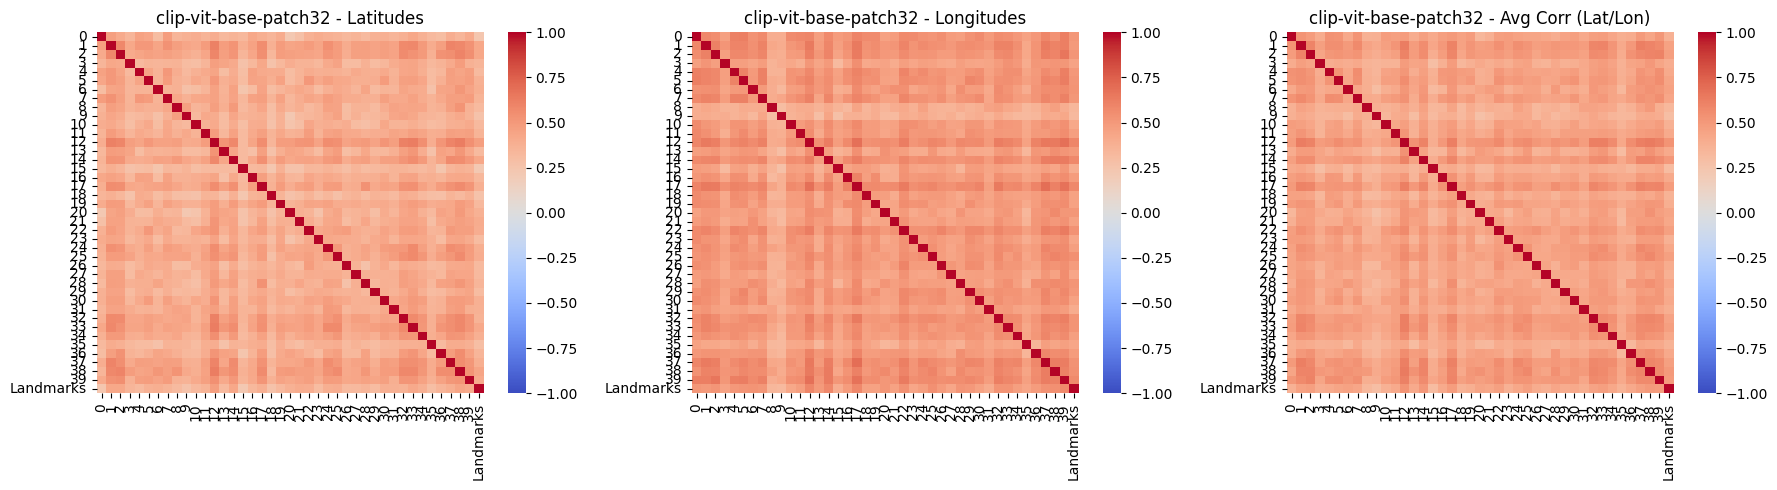

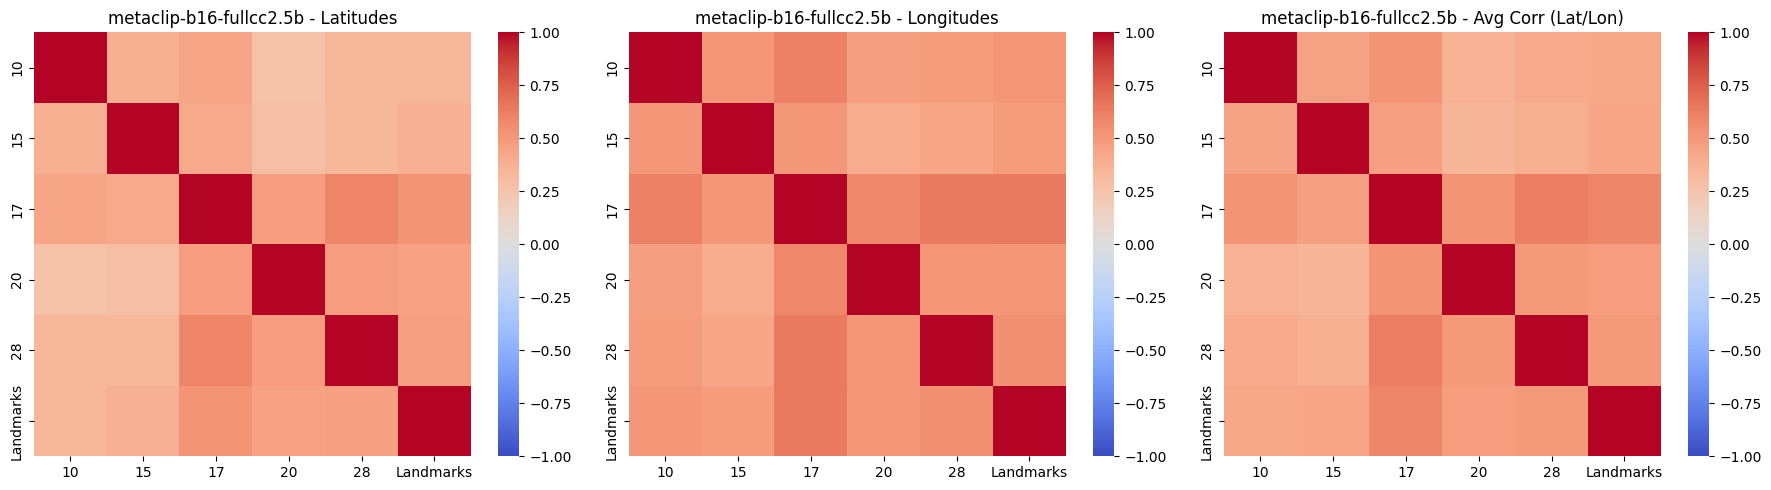

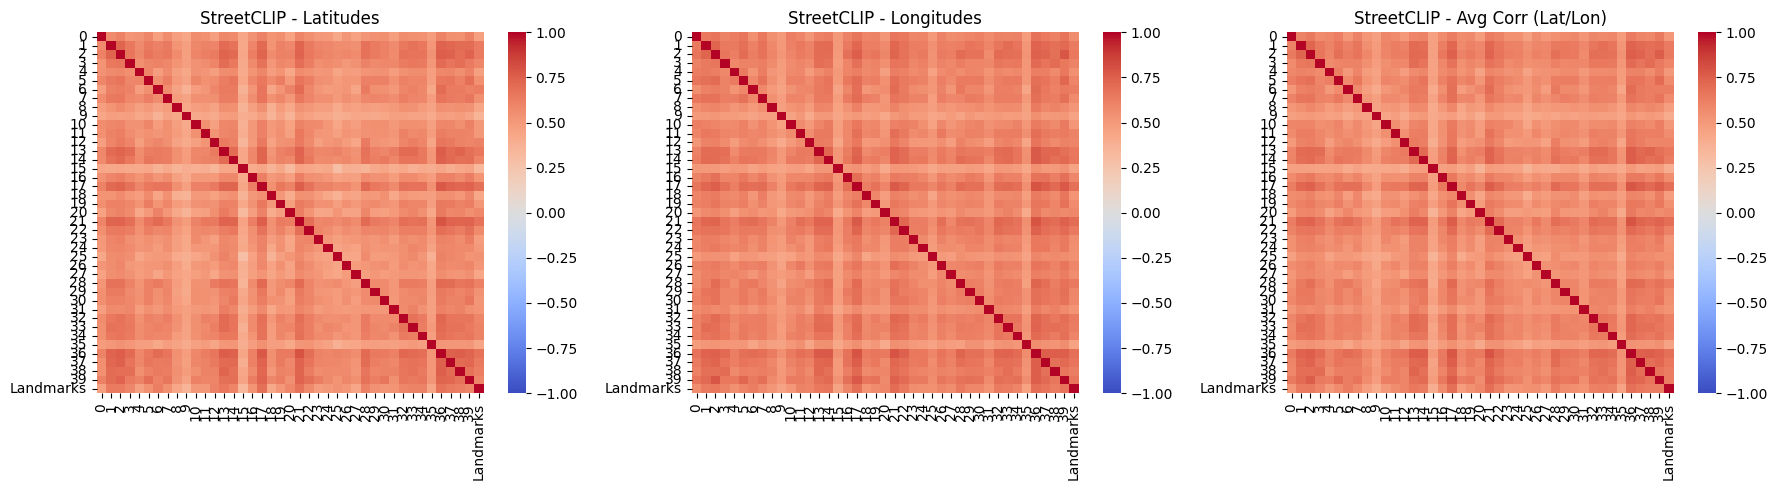

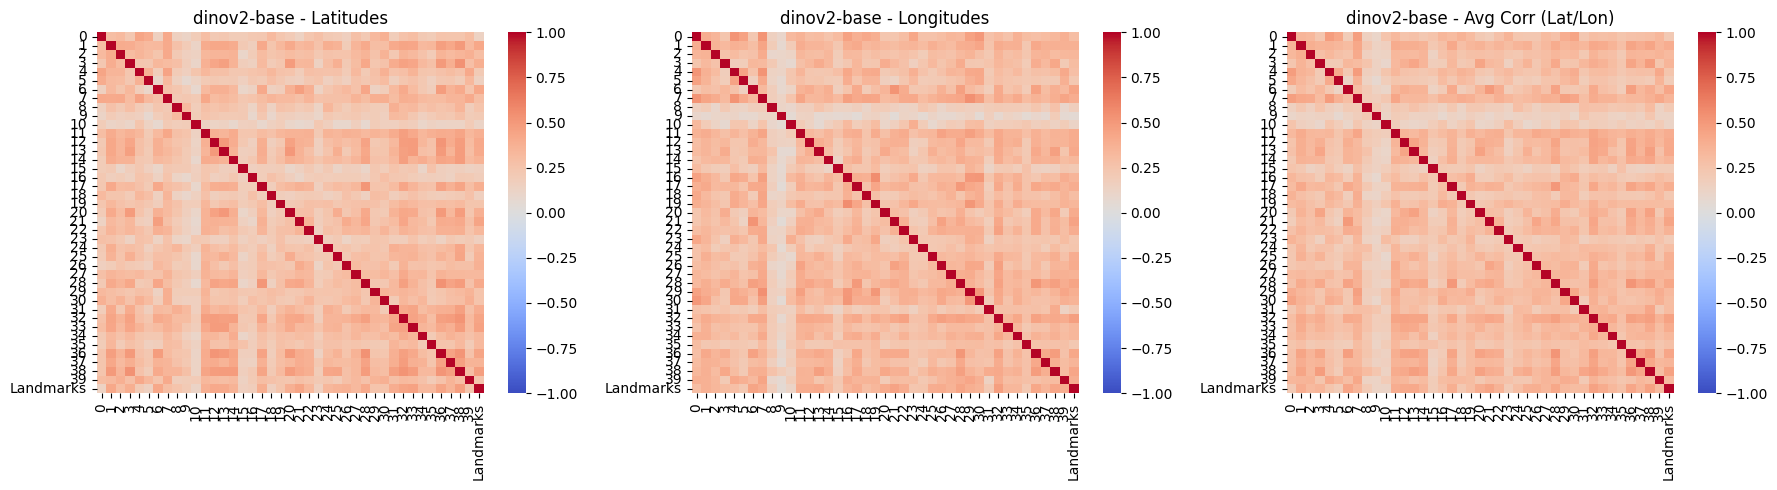

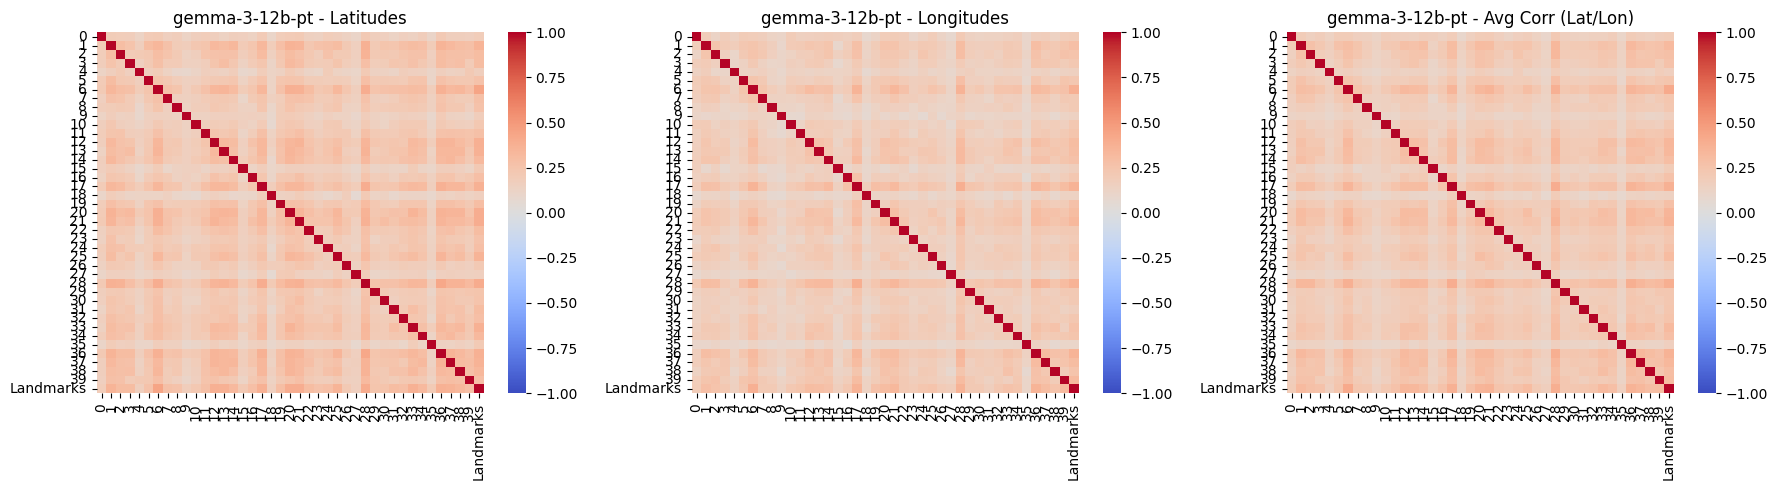

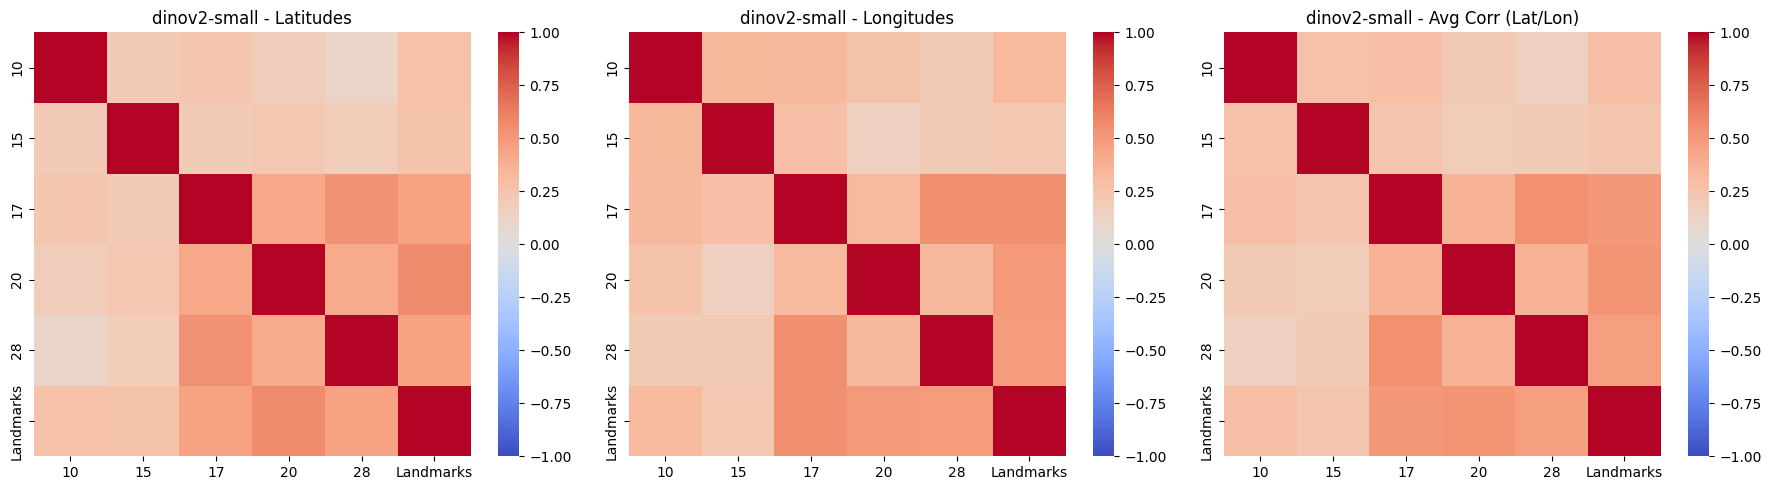

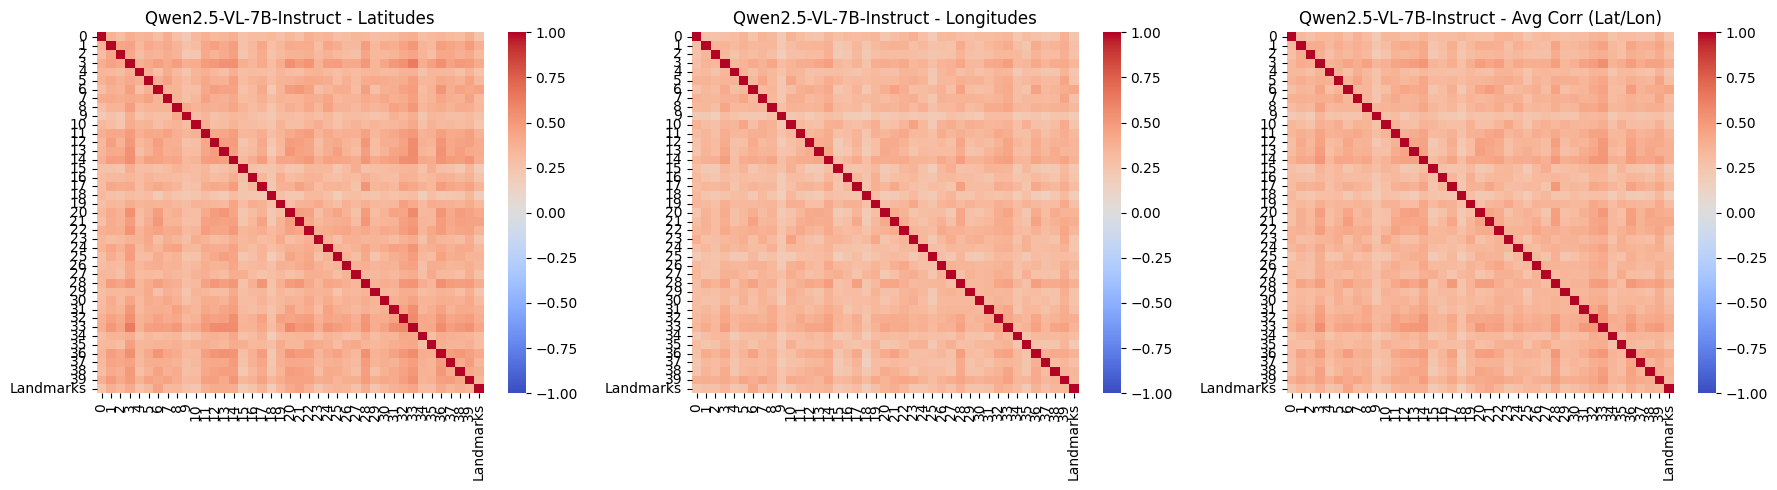

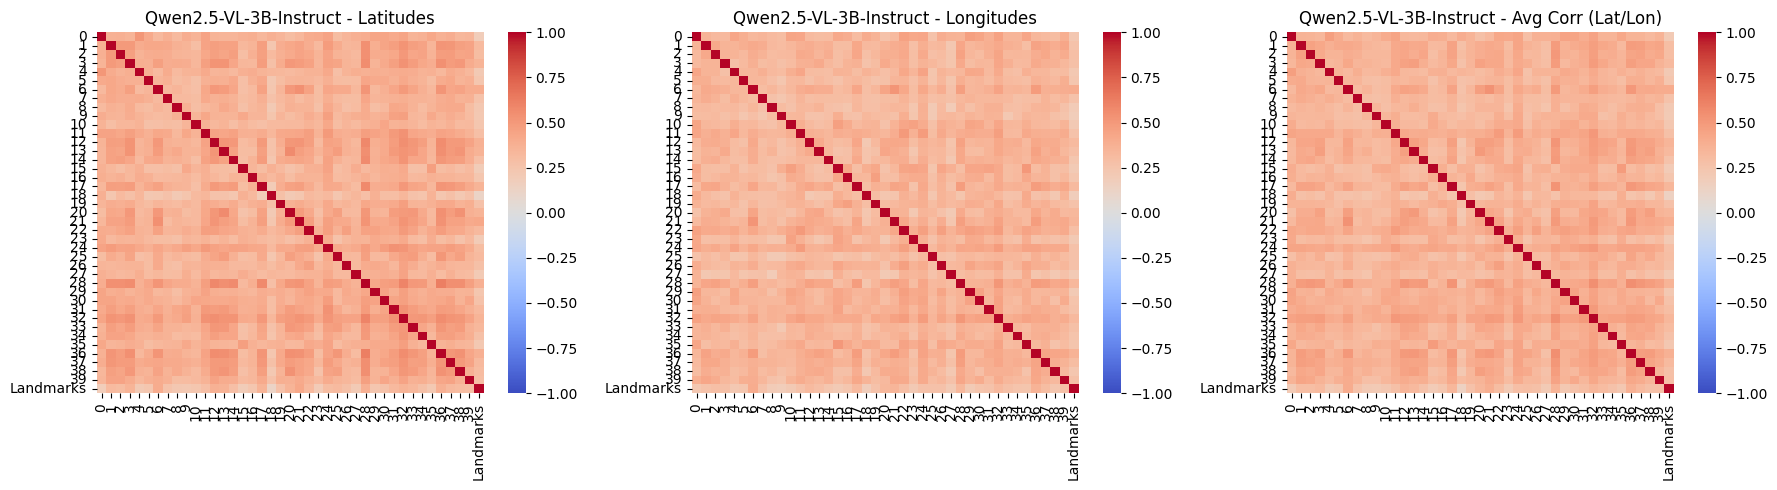

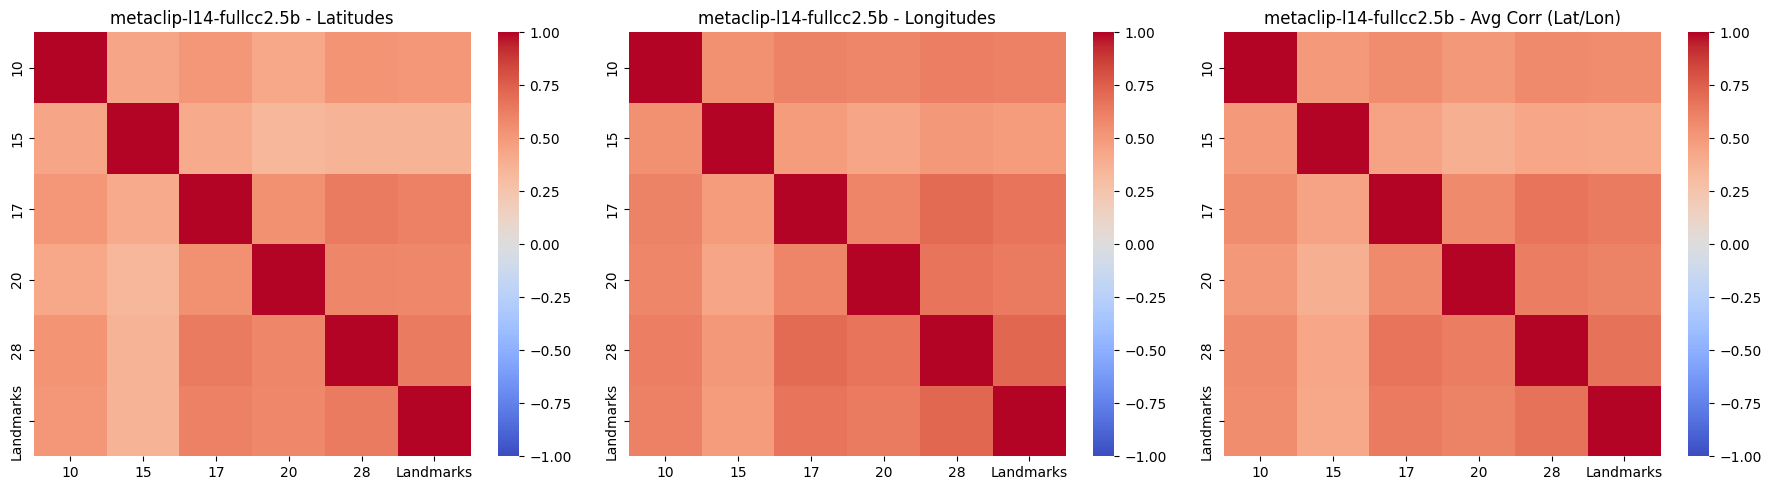

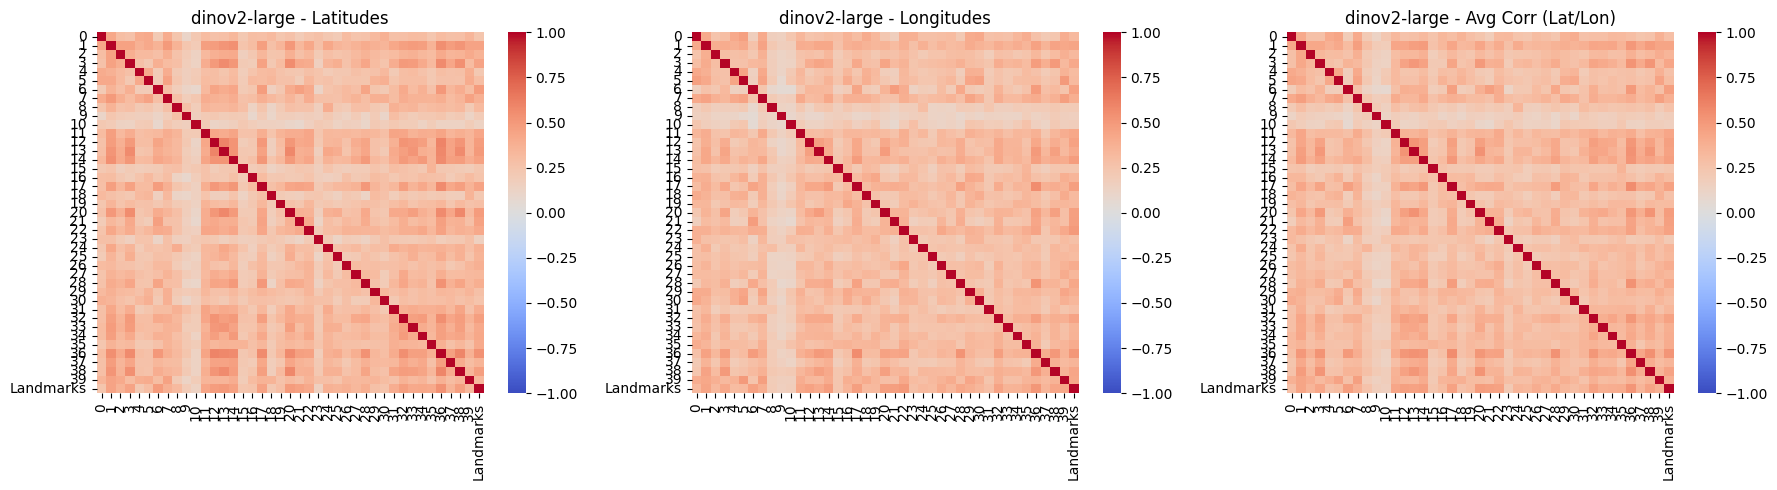

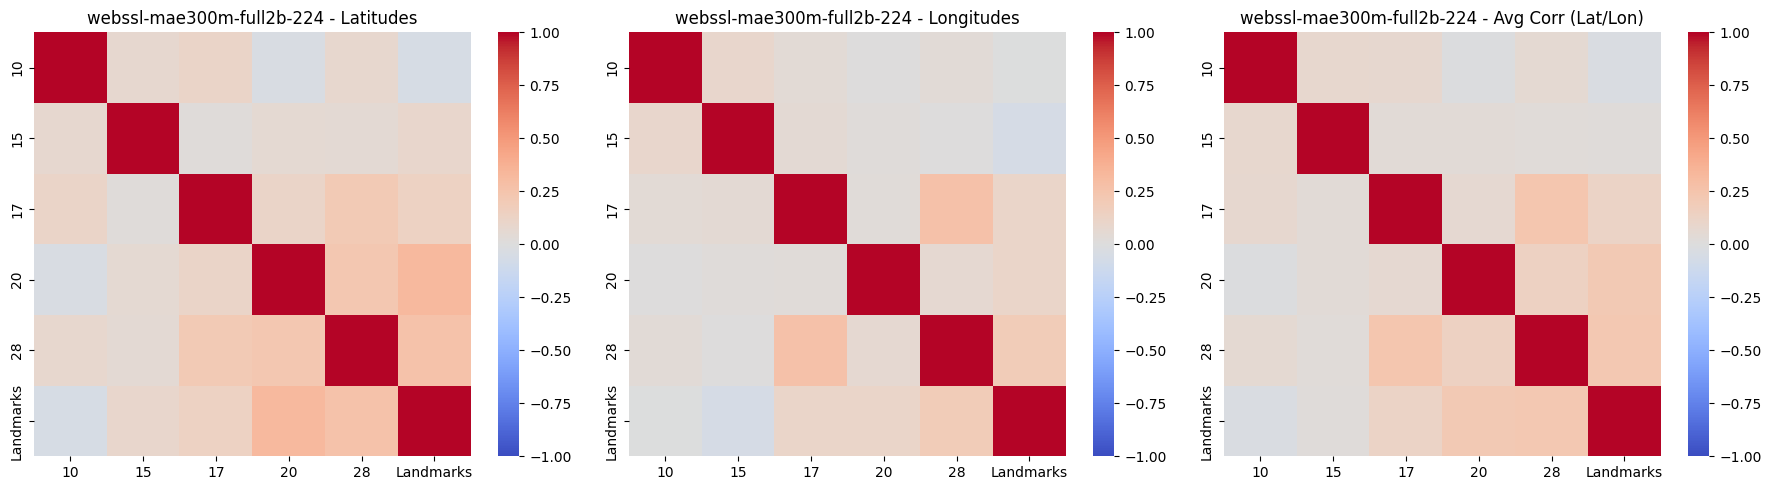

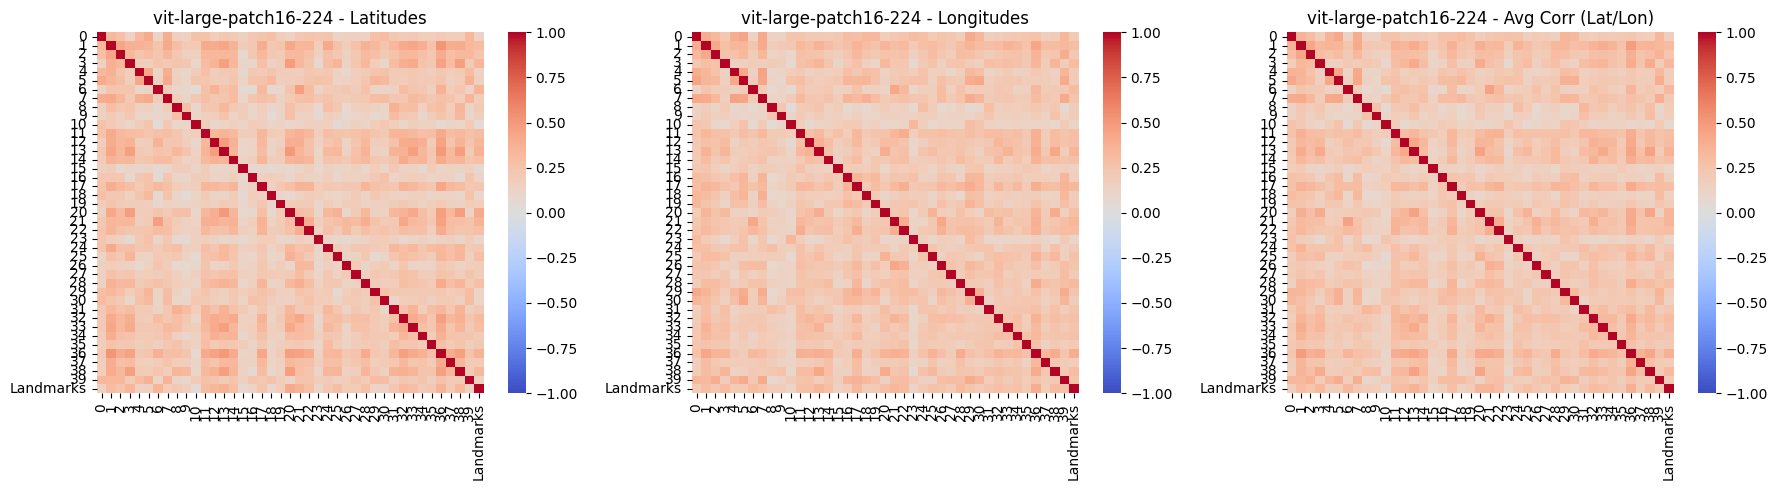

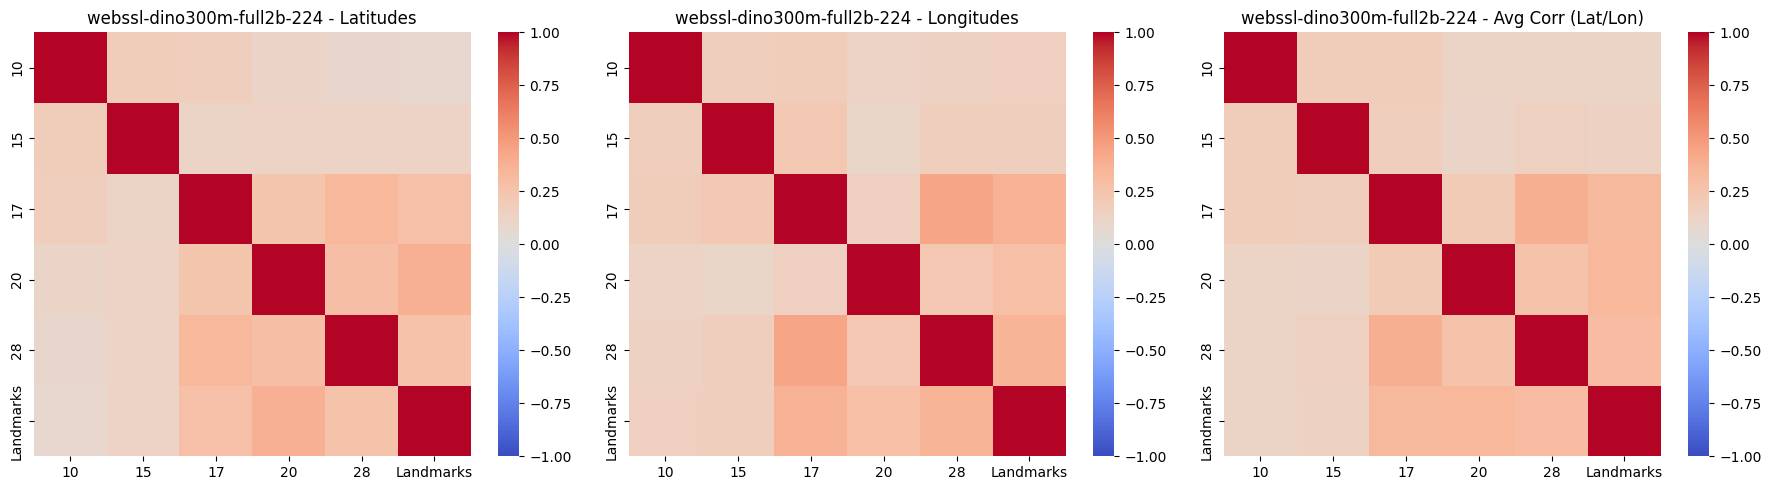

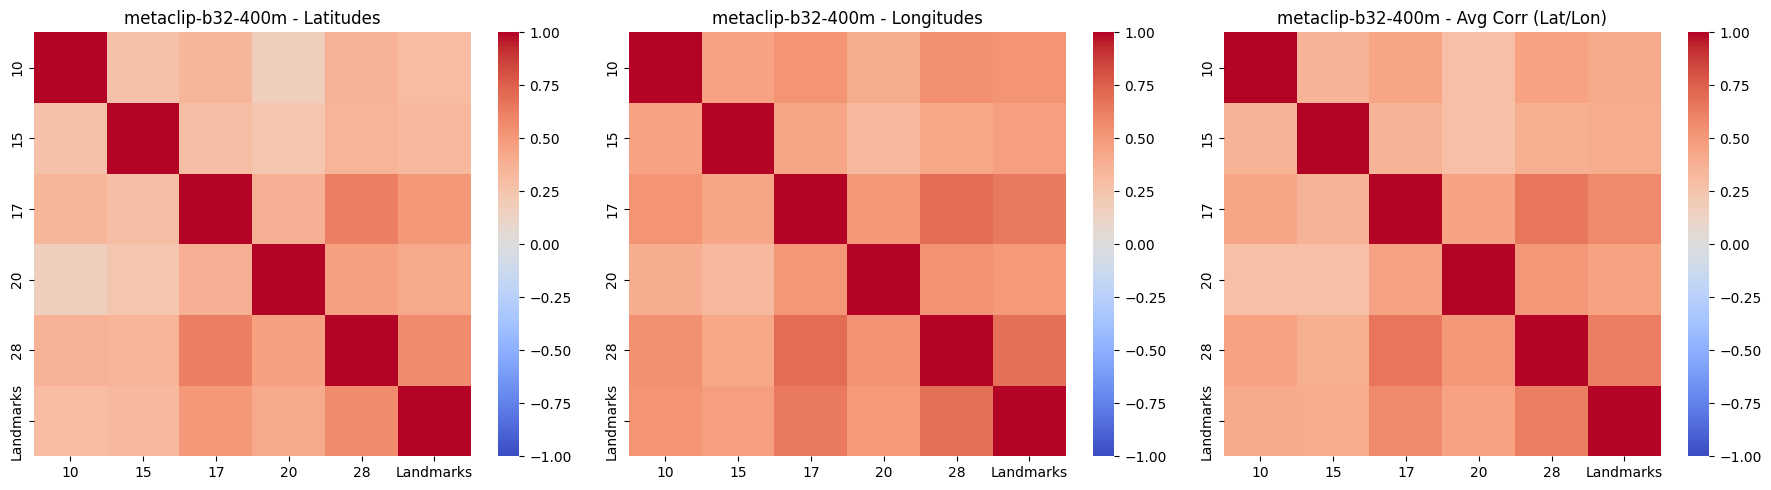

In [22]:
for model in coef_df["Model"].unique():
    aux_df=coef_df[coef_df["Model"]==model].copy()
    aux_df["temp"]=aux_df["Cluster"].apply(lambda x: x if x!="Landmarks" else 1000)
    aux_df = aux_df.sort_values(by=["temp"]).drop(columns="temp")
    # Convert lists/arrays into 2D arrays
    lat_matrix = np.vstack(aux_df["Latitude"].to_numpy())
    lon_matrix = np.vstack(aux_df["Longitude"].to_numpy())

    # Compute correlation matrices (between rows = clusters)
    corr_lat = np.corrcoef(lat_matrix)
    corr_lon = np.corrcoef(lon_matrix)

    # Average correlation matrix
    corr_avg = (corr_lat + corr_lon) / 2.0

    # Plot 3 side-by-side heatmaps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.heatmap(corr_lat, ax=axes[0], cmap="coolwarm", center=0, vmin=-1, vmax=1,yticklabels=aux_df["Cluster"].tolist(),xticklabels=aux_df["Cluster"].tolist())
    axes[0].set_title(f"{model} - Latitudes")

    sns.heatmap(corr_lon, ax=axes[1], cmap="coolwarm", center=0, vmin=-1, vmax=1,yticklabels=aux_df["Cluster"].tolist(),xticklabels=aux_df["Cluster"].tolist())
    axes[1].set_title(f"{model} - Longitudes")

    sns.heatmap(corr_avg, ax=axes[2], cmap="coolwarm", center=0, vmin=-1, vmax=1,yticklabels=aux_df["Cluster"].tolist(),xticklabels=aux_df["Cluster"].tolist())
    axes[2].set_title(f"{model} - Avg Corr (Lat/Lon)")

    plt.tight_layout()
    plt.show()


In [23]:
import numpy as np
import pandas as pd
from scipy import stats

results = []

def mean_corr_with_ci(corr_matrix, alpha=0.05):
    # take upper triangle only (excluding diagonal)
    triu_vals = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
    mean_val = np.mean(triu_vals)
    sem = stats.sem(triu_vals)
    ci = stats.t.interval(
        1 - alpha, len(triu_vals) - 1, loc=mean_val, scale=sem
    )
    return mean_val, ci

for model in coef_df["Model"].unique():
    aux_df = coef_df[coef_df["Model"] == model].copy()
    aux_df["temp"] = aux_df["Cluster"].apply(lambda x: x if x != "Landmarks" else 1000)
    aux_df = aux_df.sort_values(by=["temp"]).drop(columns="temp")

    lat_matrix = np.vstack(aux_df["Latitude"].to_numpy())
    lon_matrix = np.vstack(aux_df["Longitude"].to_numpy())

    corr_lat = np.corrcoef(lat_matrix)
    corr_lon = np.corrcoef(lon_matrix)
    corr_avg = (corr_lat + corr_lon) / 2.0

    # compute stats
    mean_lat, ci_lat = mean_corr_with_ci(corr_lat)
    mean_lon, ci_lon = mean_corr_with_ci(corr_lon)
    mean_avg, ci_avg = mean_corr_with_ci(corr_avg)

    # average R2 from df
    mean_r2 = aux_df["R2"].mean()
    sem_r2 = stats.sem(aux_df["R2"])
    ci_r2 = stats.t.interval(
        0.95, len(aux_df["R2"]) - 1, loc=mean_r2, scale=sem_r2
    )

    results.append({
        "Model": model,
        "Avg. Longitude": f"{mean_lon:.3f} ± {(ci_lon[1]-ci_lon[0])/2:.3f}",
        "Avg. Latitude": f"{mean_lat:.3f} ± {(ci_lat[1]-ci_lat[0])/2:.3f}",
        "Avg. R2": f"{mean_r2:.3f} ± {(ci_r2[1]-ci_r2[0])/2:.3f}",
    })

summary_df = pd.DataFrame(results)
print(summary_df.set_index("Model").sort_values(by="Avg. R2").to_latex())
summary_df.sort_values(by="Avg. R2")

\begin{tabular}{llll}
\toprule
 & Avg. Longitude & Avg. Latitude & Avg. R2 \\
Model &  &  &  \\
\midrule
vit-mae-base & 0.115 ± 0.005 & 0.142 ± 0.007 & 0.035 ± 0.008 \\
vit-mae-large & 0.111 ± 0.004 & 0.143 ± 0.006 & 0.051 ± 0.010 \\
webssl-mae300m-full2b-224 & 0.063 ± 0.045 & 0.112 ± 0.058 & 0.071 ± 0.052 \\
webssl-mae1b-full2b-224 & 0.109 ± 0.042 & 0.129 ± 0.045 & 0.103 ± 0.068 \\
vit-base-patch16-224 & 0.153 ± 0.004 & 0.164 ± 0.005 & 0.118 ± 0.020 \\
vit-large-patch16-224 & 0.229 ± 0.005 & 0.231 ± 0.006 & 0.145 ± 0.020 \\
webssl-dino300m-full2b-224 & 0.219 ± 0.055 & 0.195 ± 0.053 & 0.176 ± 0.111 \\
dinov2-small & 0.335 ± 0.071 & 0.314 ± 0.080 & 0.186 ± 0.123 \\
dinov2-base & 0.294 ± 0.007 & 0.283 ± 0.006 & 0.191 ± 0.033 \\
dinov2-large & 0.291 ± 0.006 & 0.312 ± 0.007 & 0.236 ± 0.037 \\
dinov2-giant & 0.300 ± 0.005 & 0.294 ± 0.006 & 0.262 ± 0.040 \\
clip-vit-base-patch32 & 0.500 ± 0.005 & 0.410 ± 0.005 & 0.278 ± 0.034 \\
webssl-dino1b-full2b-224 & 0.302 ± 0.056 & 0.248 ± 0.066 & 0.28

,Model,Avg. Longitude,Avg. Latitude,Avg. R2
0,vit-mae-base,0.115 ± 0.005,0.142 ± 0.007,0.035 ± 0.008
12,vit-mae-large,0.111 ± 0.004,0.143 ± 0.006,0.051 ± 0.010
23,webssl-mae300m-full2b-224,0.063 ± 0.045,0.112 ± 0.058,0.071 ± 0.052
10,webssl-mae1b-full2b-224,0.109 ± 0.042,0.129 ± 0.045,0.103 ± 0.068
5,vit-base-patch16-224,0.153 ± 0.004,0.164 ± 0.005,0.118 ± 0.020
24,vit-large-patch16-224,0.229 ± 0.005,0.231 ± 0.006,0.145 ± 0.020
25,webssl-dino300m-full2b-224,0.219 ± 0.055,0.195 ± 0.053,0.176 ± 0.111
18,dinov2-small,0.335 ± 0.071,0.314 ± 0.080,0.186 ± 0.123
16,dinov2-base,0.294 ± 0.007,0.283 ± 0.006,0.191 ± 0.033
22,dinov2-large,0.291 ± 0.006,0.312 ± 0.007,0.236 ± 0.037


In [24]:
## Get the correlation of the 10% most important layers
import numpy as np
import pandas as pd
from scipy import stats

results = []

for model in coef_df["Model"].unique():
    aux_df = coef_df[coef_df["Model"] == model].copy()
    aux_df["temp"] = aux_df["Cluster"].apply(lambda x: x if x != "Landmarks" else 1000)
    aux_df = aux_df.sort_values(by=["temp"]).drop(columns="temp")

    # stack into matrices
    lat_matrix_full = np.vstack(aux_df["Latitude"].to_numpy())
    lon_matrix_full = np.vstack(aux_df["Longitude"].to_numpy())

    # --- pick top 10% indices globally per model ---
    frac = 0.4
    n_coeff = lat_matrix_full.shape[1]
    k = max(1, int(n_coeff * frac))

    # get global importance (mean absolute value across clusters)
    lat_importance = np.mean(np.abs(lat_matrix_full), axis=0)
    lon_importance = np.mean(np.abs(lon_matrix_full), axis=0)

    lat_top_idx = np.argsort(lat_importance)[-k:]
    lon_top_idx = np.argsort(lon_importance)[-k:]

    # filter matrices (keep same top indices for all rows)
    lat_matrix = lat_matrix_full[:, lat_top_idx]
    lon_matrix = lon_matrix_full[:, lon_top_idx]

    corr_lat = np.corrcoef(lat_matrix)
    corr_lon = np.corrcoef(lon_matrix)
    corr_avg = (corr_lat + corr_lon) / 2.0

    # compute stats
    mean_lat, ci_lat = mean_corr_with_ci(corr_lat)
    mean_lon, ci_lon = mean_corr_with_ci(corr_lon)
    mean_avg, ci_avg = mean_corr_with_ci(corr_avg)

    # average R2 from df
    mean_r2 = aux_df["R2"].mean()
    sem_r2 = stats.sem(aux_df["R2"])
    ci_r2 = stats.t.interval(
        0.95, len(aux_df["R2"]) - 1, loc=mean_r2, scale=sem_r2
    )

    results.append({
        "Model": model,
        "Avg. Longitude": f"{mean_lon:.3f} ± {(ci_lon[1]-ci_lon[0])/2:.3f}",
        "Avg. Latitude": f"{mean_lat:.3f} ± {(ci_lat[1]-ci_lat[0])/2:.3f}",
        "Avg. R2": f"{mean_r2:.3f} ± {(ci_r2[1]-ci_r2[0])/2:.3f}",
    })

summary_df = pd.DataFrame(results)
print(summary_df.set_index("Model").sort_values(by="Avg. R2").to_latex())
summary_df.sort_values(by="Avg. R2")

\begin{tabular}{llll}
\toprule
 & Avg. Longitude & Avg. Latitude & Avg. R2 \\
Model &  &  &  \\
\midrule
vit-mae-base & 0.161 ± 0.006 & 0.195 ± 0.009 & 0.035 ± 0.008 \\
vit-mae-large & 0.153 ± 0.005 & 0.198 ± 0.007 & 0.051 ± 0.010 \\
webssl-mae300m-full2b-224 & 0.089 ± 0.054 & 0.138 ± 0.077 & 0.071 ± 0.052 \\
webssl-mae1b-full2b-224 & 0.147 ± 0.050 & 0.169 ± 0.053 & 0.103 ± 0.068 \\
vit-base-patch16-224 & 0.230 ± 0.005 & 0.253 ± 0.007 & 0.118 ± 0.020 \\
vit-large-patch16-224 & 0.351 ± 0.006 & 0.349 ± 0.008 & 0.145 ± 0.020 \\
webssl-dino300m-full2b-224 & 0.304 ± 0.062 & 0.259 ± 0.064 & 0.176 ± 0.111 \\
dinov2-small & 0.436 ± 0.081 & 0.417 ± 0.091 & 0.186 ± 0.123 \\
dinov2-base & 0.421 ± 0.008 & 0.407 ± 0.008 & 0.191 ± 0.033 \\
dinov2-large & 0.413 ± 0.007 & 0.440 ± 0.008 & 0.236 ± 0.037 \\
dinov2-giant & 0.434 ± 0.007 & 0.425 ± 0.007 & 0.262 ± 0.040 \\
clip-vit-base-patch32 & 0.674 ± 0.005 & 0.586 ± 0.005 & 0.278 ± 0.034 \\
webssl-dino1b-full2b-224 & 0.395 ± 0.065 & 0.329 ± 0.079 & 0.28

,Model,Avg. Longitude,Avg. Latitude,Avg. R2
0,vit-mae-base,0.161 ± 0.006,0.195 ± 0.009,0.035 ± 0.008
12,vit-mae-large,0.153 ± 0.005,0.198 ± 0.007,0.051 ± 0.010
23,webssl-mae300m-full2b-224,0.089 ± 0.054,0.138 ± 0.077,0.071 ± 0.052
10,webssl-mae1b-full2b-224,0.147 ± 0.050,0.169 ± 0.053,0.103 ± 0.068
5,vit-base-patch16-224,0.230 ± 0.005,0.253 ± 0.007,0.118 ± 0.020
24,vit-large-patch16-224,0.351 ± 0.006,0.349 ± 0.008,0.145 ± 0.020
25,webssl-dino300m-full2b-224,0.304 ± 0.062,0.259 ± 0.064,0.176 ± 0.111
18,dinov2-small,0.436 ± 0.081,0.417 ± 0.091,0.186 ± 0.123
16,dinov2-base,0.421 ± 0.008,0.407 ± 0.008,0.191 ± 0.033
22,dinov2-large,0.413 ± 0.007,0.440 ± 0.008,0.236 ± 0.037


In [25]:
coef_df["len"]=coef_df["Latitude"].apply(lambda x:len(x))
coef_df.groupby("Model")["len"].mean()

Model
Qwen2.5-VL-3B-Instruct        2048.0
Qwen2.5-VL-7B-Instruct        3584.0
StreetCLIP                    1024.0
clip-vit-base-patch32          768.0
clip-vit-large-patch14        1024.0
dinov2-base                    768.0
dinov2-giant                  1536.0
dinov2-large                  1024.0
dinov2-small                   384.0
gemma-3-12b-it                3840.0
gemma-3-12b-pt                3840.0
gemma-3-4b-it                 2560.0
gemma-3-4b-pt                 2560.0
llava-1.5-7b-hf               1024.0
metaclip-b16-400m              768.0
metaclip-b16-fullcc2.5b        768.0
metaclip-b32-400m              768.0
metaclip-b32-fullcc2.5b        768.0
metaclip-l14-fullcc2.5b       1024.0
vit-base-patch16-224           768.0
vit-large-patch16-224         1024.0
vit-mae-base                   768.0
vit-mae-large                 1024.0
webssl-dino1b-full2b-224      1536.0
webssl-dino300m-full2b-224    1024.0
webssl-mae1b-full2b-224       1536.0
webssl-mae300m-full2b-224     10

In [26]:
coef_df[coef_df["Model"].str.contains("llava")]

,Model,Cluster,Layer,Latitude,Longitude,R2,Type,Modality,len
299,llava-1.5-7b-hf,Landmarks,23,"[1.4505837521828253, 1.2838669147942166, -0.60...","[1.4455967210399998, -4.4913615194959595, 2.29...",0.7471014659449046,Activation,vision,1024
300,llava-1.5-7b-hf,16,23,"[1.0269113290256602, 1.1036899299017238, -0.39...","[1.832700160475139, -4.041540665822411, 1.9728...",0.4276354346695654,Activation,vision,1024
301,llava-1.5-7b-hf,12,23,"[0.8563421192988573, 1.1075304627029863, -0.36...","[0.8959853469679188, -3.4678217988466926, 1.09...",0.6560268134307671,Activation,vision,1024
302,llava-1.5-7b-hf,36,23,"[0.6546047684257961, 1.0292316192216013, 0.062...","[2.840319665047032, -2.573416962288266, 0.2521...",0.7411134513995231,Activation,vision,1024
303,llava-1.5-7b-hf,24,23,"[1.3058615787857766, 0.27651439962106567, -0.2...","[0.9547858655506969, -3.529579397155481, -0.22...",0.39100702279857863,Activation,vision,1024
304,llava-1.5-7b-hf,26,23,"[0.9827042809178538, 0.0855435540807723, 0.900...","[1.3180149814079996, -1.9655951026812428, 1.14...",0.4281668222339789,Activation,vision,1024
305,llava-1.5-7b-hf,11,23,"[1.1701450201014865, 0.8359556669694147, 0.709...","[0.669071454621542, -3.3365977808167706, -0.38...",0.46423195740173695,Activation,vision,1024
306,llava-1.5-7b-hf,10,23,"[0.6796018727725346, 0.5278541092734867, 0.444...","[0.13454751016032485, -0.7583209910676179, 0.2...",0.39758068815078645,Activation,vision,1024
307,llava-1.5-7b-hf,19,23,"[0.6738885532805521, 1.071839273738947, 0.2867...","[5.185014509718409, -1.8291251070251402, 2.673...",0.43638697440481755,Activation,vision,1024
308,llava-1.5-7b-hf,34,23,"[1.1357658783506244, 0.2672240442549699, -0.08...","[2.4322702851425673, -1.9360942633376086, 0.76...",0.46299109912206377,Activation,vision,1024


In [27]:
coef_df[coef_df["Model"].str.contains("gemma")]

,Model,Cluster,Layer,Latitude,Longitude,R2,Type,Modality,len
41,gemma-3-12b-it,Landmarks,6,"[0.018041479298168683, 0.2898554950763411, 0.1...","[0.13543254523113046, 0.8182613428017884, -0.3...",0.697090405385038,Activation,text,3840
42,gemma-3-12b-it,16,6,"[-0.05715067329597524, -0.05341979401935523, 0...","[0.1973899695696928, 0.5207021657309883, -0.00...",0.3479979193510124,Activation,text,3840
43,gemma-3-12b-it,12,6,"[0.021105071557394675, 0.29496936599003354, 0....","[0.25627662449646454, -0.05416598387204137, -0...",0.5568155269291424,Activation,text,3840
44,gemma-3-12b-it,36,6,"[-0.04255575296044406, 0.03268032996053546, 0....","[0.1488994086531612, -0.23380229144816012, -0....",0.6753910736379758,Activation,text,3840
45,gemma-3-12b-it,24,6,"[-0.02493589633857983, -0.04400456903754582, -...","[0.045250713656162324, 0.17773163339826875, -0...",0.29849867749184716,Activation,text,3840
...,...,...,...,...,...,...,...,...,...
558,gemma-3-12b-pt,17,17,"[-0.03799311950903542, 0.043417593509737624, -...","[-0.2932480496015576, -0.32336777594600374, 0....",0.7207157774516245,Activation,text,3840
559,gemma-3-12b-pt,35,17,"[0.008114302968859826, 0.05829072900649378, 0....","[-0.371749973024093, 0.06812564964395873, -0.3...",0.10322480187088749,Activation,text,3840
560,gemma-3-12b-pt,20,17,"[-0.014083261818886972, 0.09503556081522571, -...","[-0.10918174315074941, 0.0588589335828269, 0.1...",0.600863840710516,Activation,text,3840
561,gemma-3-12b-pt,0,17,"[-0.07302573404764065, -0.05028511266279601, -...","[-0.08683583557482955, 0.05345849661657809, 0....",0.34074132837783966,Activation,text,3840


# Ablations

In [28]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import h5py
from scipy import stats

# Settings
base_dir = "results/geocells_08"
r2_key = "R2"  # Change this if the R² key is named differently in your JSON

def collect_r2_stats(model_path, mode, folder=None):
    # Collect R² values from cluster files
    cluster_r2 = []
    cluster_names = []
    cluster_layers = {}
    best_modality = {}
    landmarks_r2 = None
    if folder:
        model_path = os.path.join(model_path,folder)
    for file in os.listdir(model_path):
        if file.startswith(f"{mode}_") and file.endswith(".json") and "landmark" not in file:
            cluster =int(file.split('_')[-1].rstrip('.json'))
            with open(os.path.join(model_path, file), "r") as f:
                data = json.load(f)
                r2_value=-1
                for key in data:
                    if data[key][r2_key] > r2_value:
                        r2_value = data[key][r2_key]
                        cluster_layers[cluster]=key
                        best_modality[cluster]="vision"
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        for key in data:    
                            if data[key][r2_key] > r2_value:
                                r2_value = data[key][r2_key]
                                cluster_layers[cluster]=key
                                best_modality[cluster]="text"
                if r2_value is not None:
                    cluster_r2.append(r2_value)
                    cluster_names.append(cluster)
        elif file == f"landmark_{mode}.json":   
            with open(os.path.join(model_path, file), "r") as f:
                data = json.load(f)
                landmarks_r2 = -100
                for key in data:    
                    if data[key][r2_key] > landmarks_r2:
                        landmarks_r2 = data[key][r2_key]
                        cluster_layers["Landmarks"]=key
                        best_modality["Landmarks"]="vision"
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        for key in data:    
                            if data[key][r2_key] > landmarks_r2:
                                landmarks_r2 = data[key][r2_key]
                                cluster_layers["Landmarks"]=key
                                best_modality["Landmarks"]="text"
    stats = {
        "Landmarks": landmarks_r2
    }
    stats.update({cluster_names[k]:v for k,v in enumerate(cluster_r2)})
    return stats, cluster_layers, best_modality

def gather_all_stats(mode,folder = None): 
    records = []
    for model_name in os.listdir(base_dir):
        print(model_name)
        model_path = os.path.join(base_dir, model_name)
        if not os.path.isdir(model_path):
            continue
        stats,layers,modes = collect_r2_stats(model_path, mode,folder)
        for stat_name, value in stats.items():
            if value is not None:
                records.append({
                    "Model": model_name,
                    "Cluster": stat_name,
                    "Layer":layers[stat_name],
                    "R2": value,
                    "Type": mode.capitalize(),
                    "Modality":modes[stat_name]
                })
    return pd.DataFrame(records)
df = gather_all_stats("activation","mlp")

vit-mae-base
gemma-3-12b-it
gemma-3-4b-pt
webssl-dino1b-full2b-224


FileNotFoundError: [Errno 2] No such file or directory: 'results/geocells_08/webssl-dino1b-full2b-224/mlp'

In [ ]:
df["Cluster Name"] = df["Cluster"].apply(lambda c: cluster_names[c] if c !="Landmarks" else c)
df=df[df["Model"]!="StreetCLIP"]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = df.pivot_table(
    index="Model",
    columns="Cluster Name",
    values="R2"
)
heatmap_data["avg"] = heatmap_data.mean(axis=1, numeric_only=True)
display(heatmap_data["avg"])
heatmap_data = heatmap_data.sort_values(by="avg").drop(columns="avg")

col_order = heatmap_data.mean(axis=0, numeric_only=True).sort_values().index
col_order = [c for c in col_order if "Trash" not in c]
heatmap_data = heatmap_data[col_order]

vision_only = [
    'vit-mae-base', 'vit-mae-large', 'vit-base-patch16-224',
    'vit-large-patch16-224', 'dinov2-base', 'dinov2-large', 'dinov2-giant'
]
vision_language = [
    'clip-vit-base-patch32', 'Qwen2.5-VL-3B-Instruct',
    'Qwen2.5-VL-7B-Instruct',"gemma-3-4b-it", 'gemma-3-4b-pt', 'clip-vit-large-patch14'
]



heatmap_data=heatmap_data.loc[vision_only+vision_language]
plt.figure(figsize=(12, 8))
ax =  sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=False,  # shows R² values
    fmt=".2f",
    cbar_kws={'label': 'R²'}
)

ax.set_xticklabels(ax.get_xmajorticklabels(), fontsize = 14)
ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 14)
sep_index = len(vision_only)
ax.hlines(sep_index, *ax.get_xlim(), colors="black", linewidth=2)
# Add section labels
ax.text(
    heatmap_data.shape[1] / 2, sep_index-0.35,  # x = middle of heatmap, y = just above first row
    "Vision-only",
    ha="center", va="center", fontsize=14, 
)
ax.text(
    heatmap_data.shape[1] / 2, sep_index + 0.35,  # x = middle, y = just below separation line
    "Vision-language",
    ha="center", va="center", fontsize=14, 
)
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.savefig("plots/mlp_performance_heatmap.pdf")
plt.show()

# Pooling

In [ ]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np
import h5py
from scipy import stats

# Settings
base_dir = "results/geocells_pooling"
r2_key = "R2"  # Change this if the R² key is named differently in your JSON

def collect_r2_stats(model_path, mode):
    # Collect R² values from cluster files
    cluster_r2 = []
    cluster_names = []
    cluster_layers = {}
    best_modality = {}
    landmarks_r2 = None
    wiki_r2 = None

    for file in os.listdir(model_path):
        if file.startswith(f"{mode}_") and file.endswith(".json") and "landmark" not in file:
            cluster =int(file.split('_')[-1].rstrip('.json'))
            with open(os.path.join(model_path, file), "r") as f:
                data = json.load(f)
                r2_value=-1
                for key in data:
                    if data[key][r2_key] > r2_value:
                        r2_value = data[key][r2_key]
                        cluster_layers[cluster]=key
                        best_modality[cluster]="vision"
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        for key in data:    
                            if data[key][r2_key] > r2_value:
                                r2_value = data[key][r2_key]
                                cluster_layers[cluster]=key
                                best_modality[cluster]="text"
                if r2_value is not None:
                    cluster_r2.append(r2_value)
                    cluster_names.append(cluster)
        elif file == f"landmark_{mode}.json":   
            with open(os.path.join(model_path, file), "r") as f:
                data = json.load(f)
                landmarks_r2 = -100
                for key in data:    
                    if data[key][r2_key] > landmarks_r2:
                        landmarks_r2 = data[key][r2_key]
                        cluster_layers["Landmarks"]=key
                        best_modality["Landmarks"]="vision"
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        for key in data:    
                            if data[key][r2_key] > landmarks_r2:
                                landmarks_r2 = data[key][r2_key]
                                cluster_layers["Landmarks"]=key
                                best_modality["Landmarks"]="text"
        elif file == f"wiki_{mode}.json":   
            with open(os.path.join(model_path, file), "r") as f:
                data = json.load(f)
                wiki_r2 = -100
                for key in data:    
                    if data[key][r2_key] > wiki_r2:
                        wiki_r2 = data[key][r2_key]
                        cluster_layers["Wiki"]=key
                        best_modality["Wiki"]="vision"
                if os.path.exists(os.path.join(model_path, "text_"+file)):
                    with open(os.path.join(model_path, "text_"+file), "r") as f2:
                        data = json.load(f2)
                        for key in data:    
                            if data[key][r2_key] > wiki_r2:
                                wiki_r2 = data[key][r2_key]
                                cluster_layers["Wiki"]=key
                                best_modality["Wiki"]="text"
    stats = {
        "Landmarks": landmarks_r2,
        #"Wiki":wiki_r2,
    }
    stats.update({cluster_names[k]:v for k,v in enumerate(cluster_r2)})
    return stats, cluster_layers, best_modality

def gather_all_stats(mode): 
    records = []
    for model_name in os.listdir(base_dir):
        print(model_name)
        model_path = os.path.join(base_dir, model_name)
        if not os.path.isdir(model_path):
            continue
        stats,layers,modes = collect_r2_stats(model_path, mode)
        for stat_name, value in stats.items():
            if value is not None:
                records.append({
                    "Model": model_name,
                    "Cluster": stat_name,
                    "Layer":layers[stat_name],
                    "R2": value,
                    "Type": mode.capitalize(),
                    "Modality":modes[stat_name]
                })
    return pd.DataFrame(records)
df = gather_all_stats("activation")
df=df[df["Model"]!="StreetCLIP"]

In [ ]:
df["Cluster Name"] = df["Cluster"].apply(lambda c: cluster_names[c] if c !="Landmarks" else c)

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = df.pivot_table(
    index="Model",
    columns="Cluster Name",
    values="R2"
)
heatmap_data["avg"] = heatmap_data.mean(axis=1, numeric_only=True)
display(heatmap_data["avg"].sort_values())
heatmap_data = heatmap_data.sort_values(by="avg").drop(columns="avg")

col_order = heatmap_data.mean(axis=0, numeric_only=True).sort_values().index
col_order = [c for c in col_order if "Trash" not in c]
heatmap_data = heatmap_data[col_order]

vision_only = [
    'vit-mae-base', 'vit-mae-large', 'vit-base-patch16-224',
    'vit-large-patch16-224', 'dinov2-base', 'dinov2-large', 'dinov2-giant'
]
vision_language = [
    'clip-vit-base-patch32', 'Qwen2.5-VL-3B-Instruct',
    'Qwen2.5-VL-7B-Instruct',"gemma-3-4b-it", 'gemma-3-4b-pt' , 'clip-vit-large-patch14', 'llava-1.5-7b-hf'
]

heatmap_data=heatmap_data.loc[vision_only+vision_language]

plt.figure(figsize=(12, 8))
ax =  sns.heatmap(
    heatmap_data,
    cmap="Blues",
    annot=False,  # shows R² values
    fmt=".2f",
    cbar_kws={'label': 'R²'}
)

ax.set_xticklabels(ax.get_xmajorticklabels(), fontsize = 14)
ax.set_yticklabels(ax.get_ymajorticklabels(), fontsize = 14)
sep_index = len(vision_only)
ax.hlines(sep_index, *ax.get_xlim(), colors="black", linewidth=2)
# Add section labels
ax.text(
    heatmap_data.shape[1] / 2, sep_index-0.35,  # x = middle of heatmap, y = just above first row
    "Vision-only",
    ha="center", va="center", fontsize=14, 
)
ax.text(
    heatmap_data.shape[1] / 2, sep_index + 0.35,  # x = middle, y = just below separation line
    "Vision-language",
    ha="center", va="center", fontsize=14, 
)
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.savefig("plots/pooling_performance_heatmap.pdf")
plt.show()

In [ ]:
heatmap_data